# Heating Correction ML — Offline Standalone Training & Feature Ablation

**Purpose:** Reproduce the LightGBM heating-correction regressor training offline,
using the exported `heating_training_data.csv.gz`. Enables:

1. **Feature ablation** — comment out individual features or whole groups to test R² / MAE impact
2. **`indoor_temp` dominance diagnosis** — why does permutation importance show 0.4956 for `indoor_temp` while all others are < 0.01?
3. **Missing feature analysis** — residual patterns that hint at missing signals
4. **Full diagnostic dashboard** — calibration plots, time-series overlays, residual analysis

**Reference:** Output format matches the Home Assistant add-on log (`HA_LOG.txt`) so results can be compared 1:1.

**Data source:** `Logs_and_models/heating_training_data.csv.gz` — exported by the calibration script after each training run.

## 0. Configuration

In [1]:
import os

# ── Paths ────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = os.path.abspath(os.getcwd())
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, "../.."))
LOGS_DIR = os.path.join(PROJECT_ROOT, "Logs_and_models")

TRAINING_CSV = os.path.join(LOGS_DIR, "heating_training_data.csv.gz")
METADATA_JSON = os.path.join(LOGS_DIR, "heating_correction_ml_metadata.json")

# ── Label & physics ────────────────────────────────────────────────────────────
LABEL_HORIZON_H = 4              # hours ahead for label computation
STEPS_PER_HOUR = 6               # 10-min resolution
HEATING_TARGET_C = 22.6          # indoor target temperature
COLD_THRESHOLD_C = 18.0          # AT < this for cold-season filter
SPECIFIC_HEAT = 4.186            # kJ/(kg·K)
SHADING_ACTIVATION_TEMP_C = 23.0 # shading proxy threshold

# ── Train / test split ────────────────────────────────────────────────────────
TRAIN_FRACTION = 0.75

# ── LightGBM defaults (from latest Optuna run — May 20, 2026) ──────────────
LGB_PARAMS = {
    "objective": "regression_l1",
    "metric": "mae",
    "n_estimators": 300,
    "learning_rate": 0.08967,
    "max_depth": 4,
    "num_leaves": 55,
    "min_child_samples": 29,
    "reg_alpha": 0.6597,
    "reg_lambda": 3.6333,
    "random_state": 42,
    "n_jobs": -1,
    "verbose": -1,
}

print("Config loaded.")
print(f"  Training CSV : {TRAINING_CSV}")
print(f"  Metadata JSON: {METADATA_JSON}")
print(f"  Label horizon: {LABEL_HORIZON_H}h ({LABEL_HORIZON_H * STEPS_PER_HOUR} steps)")
print(f"  Target temp  : {HEATING_TARGET_C}°C")

Config loaded.
  Training CSV : c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\Logs_and_models\heating_training_data.csv.gz
  Metadata JSON: c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\Logs_and_models\heating_correction_ml_metadata.json
  Label horizon: 4h (24 steps)
  Target temp  : 22.6°C


## 1. Imports

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.inspection import permutation_importance

try:
    import lightgbm as lgb
    USE_LGBM = True
    print("LightGBM available ✓")
except ImportError:
    USE_LGBM = False
    print("LightGBM not found — install with: pip install lightgbm")

try:
    import shap
    USE_SHAP = True
    print("SHAP available ✓")
except ImportError:
    USE_SHAP = False
    print("SHAP not found — install with: pip install shap (optional)")

try:
    import optuna
    USE_OPTUNA = True
    print("Optuna available ✓")
except ImportError:
    USE_OPTUNA = False
    print("Optuna not found — install with: pip install optuna (optional)")

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (16, 5)
print("\nImports OK")

LightGBM available ✓
SHAP available ✓
Optuna available ✓

Imports OK


## 2. Data Loading

In [3]:
# ── Load training data ────────────────────────────────────────────────────────
df = pd.read_csv(TRAINING_CSV)
print(f"Loaded {len(df):,} rows × {df.shape[1]} columns from {os.path.basename(TRAINING_CSV)}")
print(f"\nColumns ({df.shape[1]}):")
for i, c in enumerate(df.columns):
    print(f"  {i+1:2d}. {c}")

# ── Load baseline metadata for comparison ─────────────────────────────────────
baseline_meta = None
if os.path.exists(METADATA_JSON):
    with open(METADATA_JSON) as fh:
        baseline_meta = json.load(fh)
    print(f"\nBaseline model metadata loaded:")
    print(f"  Trained at : {baseline_meta.get('trained_at', 'N/A')}")
    print(f"  Val MAE    : {baseline_meta.get('val_mae', 'N/A'):.4f}°C")
    print(f"  Val R²     : {baseline_meta.get('val_r2', 'N/A'):.4f}")
    print(f"  Features   : {baseline_meta.get('n_features', 'N/A')}")
    print(f"  S_H        : {baseline_meta.get('s_h_estimated', 'N/A'):.4f}")

# ── Label statistics ──────────────────────────────────────────────────────────
print(f"\nLabel statistics:")
print(f"  mean = {df['label'].mean():.3f}")
print(f"  std  = {df['label'].std():.3f}")
print(f"  min  = {df['label'].min():.3f}")
print(f"  max  = {df['label'].max():.3f}")
print(f"  Positive (undershoot) : {(df['label'] > 0).sum():,} ({(df['label'] > 0).mean()*100:.1f}%)")
print(f"  Negative (overshoot)  : {(df['label'] < 0).sum():,} ({(df['label'] < 0).mean()*100:.1f}%)")
print(f"  Zero (on target)      : {(df['label'] == 0).sum():,} ({(df['label'] == 0).mean()*100:.1f}%)")

Loaded 85,078 rows × 52 columns from heating_training_data.csv.gz

Columns (52):
   1. indoor_temp
   2. indoor_margin
   3. indoor_trend_30m
   4. indoor_trend_1h
   5. AT
   6. at_delta_indoor
   7. AT_roh_1h
   8. AT_roh_2h
   9. AT_roh_3h
  10. AT_roh_4h
  11. VLT
  12. RLT
  13. delta_t
  14. outlet_indoor_diff
  15. thermal_power_w
  16. fireplace_on
  17. tv_on
  18. fireplace_lag_1h
  19. fireplace_lag_2h
  20. fireplace_lag_3h
  21. fireplace_lag_4h
  22. tv_lag_30m
  23. tv_lag_1h
  24. PV_Generate
  25. pv_roll_1h
  26. pv_roll_2h
  27. pv_forecast_1h
  28. pv_forecast_2h
  29. pv_forecast_3h
  30. pv_forecast_4h
  31. hour_sin
  32. hour_cos
  33. doy_sin
  34. doy_cos
  35. wind_speed
  36. indoor_temp_gradient
  37. living_room_temp
  38. is_hp_active
  39. is_weekend
  40. thermal_power_rolling_1h
  41. indoor_margin_rate
  42. is_overshoot
  43. d_inlet_temp_60min
  44. is_equilibrium
  45. heat_loss_driving_force
  46. delta_T_indoor_lag1
  47. Q_wp
  48. solar_thermal

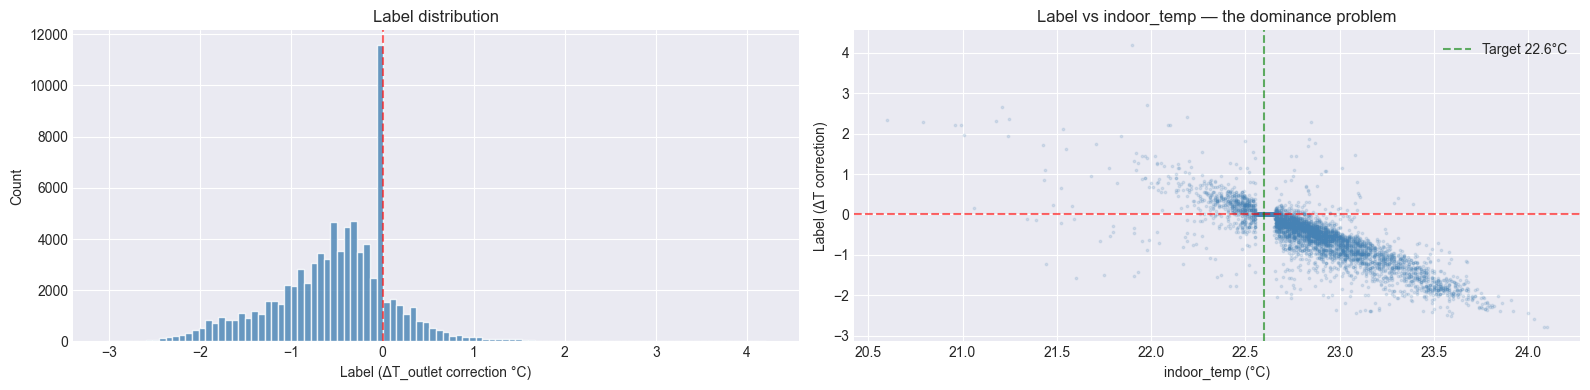

In [4]:
# ── Label distribution plot ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].hist(df["label"], bins=100, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(0, color="red", linestyle="--", alpha=0.6)
axes[0].set_xlabel("Label (ΔT_outlet correction °C)")
axes[0].set_ylabel("Count")
axes[0].set_title("Label distribution")

# Label vs indoor_temp scatter
sample_idx = np.random.RandomState(42).choice(len(df), min(5000, len(df)), replace=False)
axes[1].scatter(df["indoor_temp"].iloc[sample_idx], df["label"].iloc[sample_idx],
                alpha=0.15, s=3, color="steelblue")
axes[1].axhline(0, color="red", linestyle="--", alpha=0.6)
axes[1].axvline(HEATING_TARGET_C, color="green", linestyle="--", alpha=0.6, label=f"Target {HEATING_TARGET_C}°C")
axes[1].set_xlabel("indoor_temp (°C)")
axes[1].set_ylabel("Label (ΔT correction)")
axes[1].set_title("Label vs indoor_temp — the dominance problem")
axes[1].legend()

plt.tight_layout()
plt.show()

### 2b. Enrich with Solar Radiation from Open-Meteo (Historical Archive API)

The CSV has no direct **shortwave radiation** sensor. We fetch it from the
[Open-Meteo Historical Weather API](https://open-meteo.com/en/docs/historical-weather-api)
(free, no API key needed for non-commercial use).

- **Endpoint:** `archive-api.open-meteo.com/v1/archive`
- **Variable:** `shortwave_radiation` — total global horizontal irradiance (W/m²), hourly average
- **Resolution:** hourly → interpolated to CSV resolution (~6 min)

#### Home Assistant integration
You can also get this data **live in Home Assistant**:
1. Install the **Open-Meteo** integration (Settings → Integrations → Add → "Open-Meteo")
2. It creates a `weather.open_meteo` entity, but does NOT expose hourly shortwave_radiation directly.
3. **Better option:** Add a [REST sensor](https://www.home-assistant.io/integrations/rest/) to `configuration.yaml`:
```yaml
sensor:
  - platform: rest
    name: "Solar Radiation"
    resource: "https://api.open-meteo.com/v1/forecast?latitude=48.928&longitude=10.069&current=shortwave_radiation"
    value_template: "{{ value_json.current.shortwave_radiation }}"
    unit_of_measurement: "W/m²"
    scan_interval: 600  # every 10 minutes
```
This sensor can then be used by the calibration script as a feature for real-time prediction.

Fetching solar radiation from Open-Meteo Historical API…
  Location: 48.928°N, 10.069°E
  Period:   2025-06-01 → 2026-05-20
  ⚠️  SSL verification failed (corporate proxy?) — retrying without verify…
  Received: 8,496 hourly data points
  Range:    2025-06-01 00:00:00 → 2026-05-20 23:00:00
  Mean:     144.3 W/m²
  Max:      907.0 W/m²

  CSV resolution: ~6.0 min (85,078 rows over 2025-06-01→2026-05-20)

✓ Added 'shortwave_radiation_wm2' to DataFrame
  Non-zero: 48,211 / 85,078 (56.7%)
  Mean:     144.1 W/m²
  Corr with PV_Generate: 0.037
  Corr with label:       -0.048


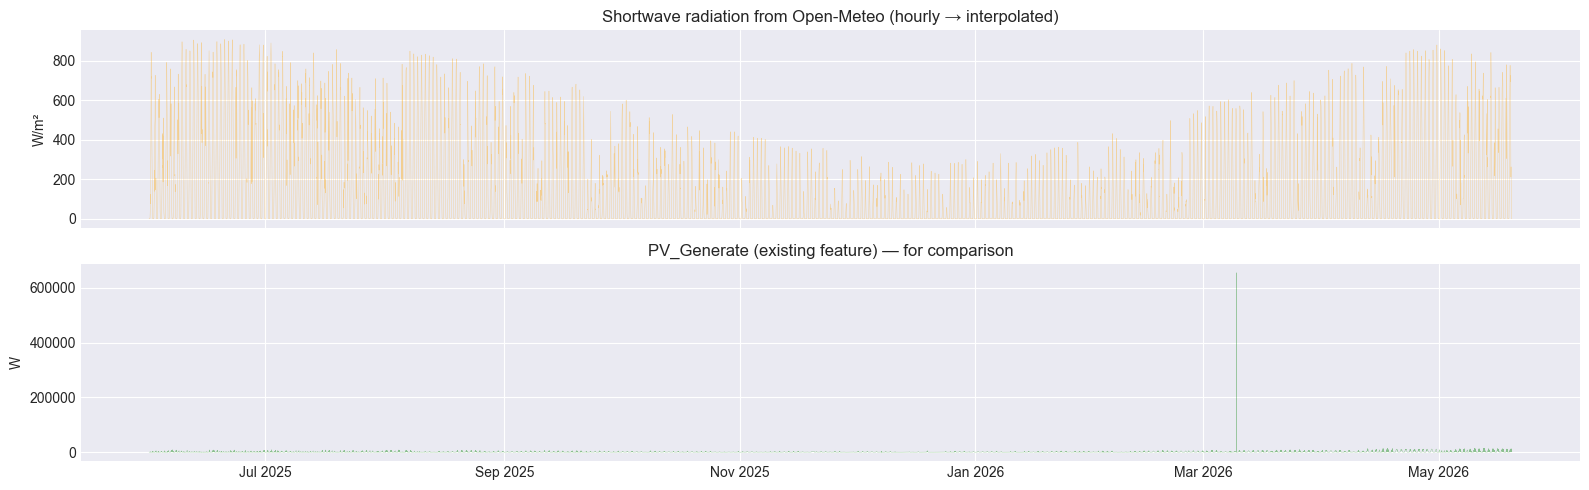

In [6]:
import requests
import urllib3

# ── Open-Meteo: Fetch historical shortwave_radiation ──────────────────────────
LATITUDE = 48.928
LONGITUDE = 10.069
START_DATE = "2025-06-01"
END_DATE = "2026-05-20"

url = (
    f"https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={LATITUDE}&longitude={LONGITUDE}"
    f"&start_date={START_DATE}&end_date={END_DATE}"
    f"&hourly=shortwave_radiation"
    f"&timezone=Europe%2FBerlin"
)

print(f"Fetching solar radiation from Open-Meteo Historical API…")
print(f"  Location: {LATITUDE}°N, {LONGITUDE}°E")
print(f"  Period:   {START_DATE} → {END_DATE}")

# Try with SSL verification first, fall back to verify=False for corporate proxies
try:
    resp = requests.get(url, timeout=120)
except requests.exceptions.SSLError:
    print("  ⚠️  SSL verification failed (corporate proxy?) — retrying without verify…")
    urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
    resp = requests.get(url, timeout=120, verify=False)

resp.raise_for_status()
solar_data = resp.json()

solar_hourly = pd.DataFrame({
    "timestamp": pd.to_datetime(solar_data["hourly"]["time"]),
    "shortwave_radiation_wm2": solar_data["hourly"]["shortwave_radiation"],
})
solar_hourly = solar_hourly.set_index("timestamp")
# Fill any null values from the API with 0 (nighttime gaps)
solar_hourly["shortwave_radiation_wm2"] = solar_hourly["shortwave_radiation_wm2"].fillna(0)

print(f"  Received: {len(solar_hourly):,} hourly data points")
print(f"  Range:    {solar_hourly.index[0]} → {solar_hourly.index[-1]}")
print(f"  Mean:     {solar_hourly['shortwave_radiation_wm2'].mean():.1f} W/m²")
print(f"  Max:      {solar_hourly['shortwave_radiation_wm2'].max():.1f} W/m²")

# ── Create synthetic timestamps for the CSV rows ─────────────────────────────
# CSV has no timestamp column. Reconstruct from known data range + row count.
csv_timestamps = pd.date_range(start=START_DATE, end=END_DATE, periods=len(df))
step_minutes = (csv_timestamps[1] - csv_timestamps[0]).total_seconds() / 60
print(f"\n  CSV resolution: ~{step_minutes:.1f} min ({len(df):,} rows over {START_DATE}→{END_DATE})")

df.index = csv_timestamps

# ── Resample hourly solar data to CSV resolution and merge ────────────────────
# Interpolate hourly values to the CSV's finer resolution
resample_freq = f"{max(1, int(round(step_minutes)))}min"
solar_fine = solar_hourly.resample(resample_freq).interpolate(method="linear")

# Align to the CSV index using nearest-neighbor matching
df["shortwave_radiation_wm2"] = solar_fine["shortwave_radiation_wm2"].reindex(
    df.index, method="nearest", tolerance=pd.Timedelta(minutes=15)
).values

# Fill remaining edge NaNs with 0
df["shortwave_radiation_wm2"] = df["shortwave_radiation_wm2"].fillna(0)

print(f"\n✓ Added 'shortwave_radiation_wm2' to DataFrame")
print(f"  Non-zero: {(df['shortwave_radiation_wm2'] > 0).sum():,} / {len(df):,} "
      f"({(df['shortwave_radiation_wm2'] > 0).mean()*100:.1f}%)")
print(f"  Mean:     {df['shortwave_radiation_wm2'].mean():.1f} W/m²")
print(f"  Corr with PV_Generate: {df[['shortwave_radiation_wm2','PV_Generate']].corr().iloc[0,1]:.3f}")
print(f"  Corr with label:       {df[['shortwave_radiation_wm2','label']].corr().iloc[0,1]:.3f}")

# ── Quick visualization ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 5), sharex=True)
axes[0].plot(df.index, df["shortwave_radiation_wm2"], alpha=0.4, linewidth=0.3, color="orange")
axes[0].set_ylabel("W/m²")
axes[0].set_title("Shortwave radiation from Open-Meteo (hourly → interpolated)")

axes[1].plot(df.index, df["PV_Generate"], alpha=0.4, linewidth=0.3, color="green")
axes[1].set_ylabel("W")
axes[1].set_title("PV_Generate (existing feature) — for comparison")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.tight_layout()
plt.show()

## 3. Feature Selection (Commentable)

**To test feature ablation:** comment out individual lines with `#` and re-run from here.

Each feature is on its own line so you can easily toggle it.

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# FEATURE SELECTION — comment out lines with # to exclude features from training
# ══════════════════════════════════════════════════════════════════════════════

FEATURE_COLS = [
    # ── Indoor state ──────────────────────────────────────────────────────────
    "indoor_temp",               # Current indoor temperature
    "indoor_margin",             # indoor_temp - heating_target (distance to setpoint)
    "indoor_trend_30m",          # 30-min indoor temp change
    "indoor_trend_1h",           # 1h indoor temp change
    "indoor_temp_gradient",      # Rate of change (°C/h)
    "indoor_margin_rate",        # Rate of change of margin (°C/h)
    "is_overshoot",              # Binary: indoor_temp > target

    # ── Outdoor temperature & forecasts ───────────────────────────────────────
    "AT",                        # Current outdoor temperature
    "at_delta_indoor",           # AT - indoor_temp
    "AT_roh_1h",                 # AT forecast/hindcast 1h
    "AT_roh_2h",                 # AT forecast/hindcast 2h
    "AT_roh_3h",                 # AT forecast/hindcast 3h
    "AT_roh_4h",                 # AT forecast/hindcast 4h

    # ── PV / Solar ────────────────────────────────────────────────────────────
    "PV_Generate",               # Current PV generation (W)
    "pv_roll_1h",                # 1h rolling mean PV
    "pv_roll_2h",                # 2h rolling mean PV
    "pv_forecast_1h",            # PV forecast 1h
    "pv_forecast_2h",            # PV forecast 2h
    "pv_forecast_3h",            # PV forecast 3h
    "pv_forecast_4h",            # PV forecast 4h
    "pv_forecast_delta",         # pv_forecast_2h - PV_Generate
    "solar_thermal_proxy",       # PV_Generate × cos(hour)
    "shading_proxy",             # max(0, indoor-23) × PV_Generate
    "shortwave_radiation_wm2",   # Global horizontal irradiance (W/m²) from Open-Meteo

    # ── HP thermal state ──────────────────────────────────────────────────────
    "VLT",                       # Supply temperature (Vorlauf)
    "RLT",                       # Return temperature (Rücklauf)
    "delta_t",                   # VLT - RLT
    "outlet_indoor_diff",        # VLT - indoor_temp
    "thermal_power_w",           # Thermal power (W)
    "thermal_power_rolling_1h",  # 1h rolling mean thermal power
    "Q_wp",                      # Heat output (flow × ΔT × c_p) in W

    # ── External heat sources ─────────────────────────────────────────────────
    "fireplace_on",              # Fireplace active (binary)
    "fireplace_lag_1h",          # Fireplace residual heat (1h window)
    "fireplace_lag_2h",          # Fireplace residual heat (2h window)
    "fireplace_lag_3h",          # Fireplace residual heat (3h window)
    "fireplace_lag_4h",          # Fireplace residual heat (4h window)
    "tv_on",                     # TV active (binary)
    "tv_lag_30m",                # TV residual heat (30m window)
    "tv_lag_1h",                 # TV residual heat (1h window)

    # ── Slab thermal state ────────────────────────────────────────────────────
    "d_inlet_temp_60min",        # RLT change over 60min
    "is_equilibrium",            # |d_inlet_temp_60min| < 0.3K

    # ── Context / physics interactions ────────────────────────────────────────
    "wind_speed",                # Wind speed (m/s)
    "living_room_temp",          # Living room temperature
    "is_hp_active",              # Heat pump active (|delta_t| > 1K)
    "is_weekend",                # Saturday/Sunday
    "heat_loss_driving_force",   # indoor_temp - AT (Newton cooling)
    "delta_T_indoor_lag1",       # indoor_temp.diff(1) — autoregressive momentum
    "heat_loss_interaction",     # (indoor_temp - AT) × wind_speed

    # ── Cyclical time ─────────────────────────────────────────────────────────
    "hour_sin",                  # sin(2π × hour/24)
    "hour_cos",                  # cos(2π × hour/24)
    "doy_sin",                   # sin(2π × day_of_year/365)
    "doy_cos",                   # cos(2π × day_of_year/365)
]

# ── Validate: keep only columns that exist in the CSV or enriched df ──────────
available = [c for c in FEATURE_COLS if c in df.columns]
missing = [c for c in FEATURE_COLS if c not in df.columns]
if missing:
    print(f"⚠️  {len(missing)} features not in DataFrame (skipped): {missing}")
FEATURE_COLS = available

print(f"\n✓ Using {len(FEATURE_COLS)} features for training")
for i, f in enumerate(FEATURE_COLS):
    print(f"  {i+1:2d}. {f}")


✓ Using 52 features for training
   1. indoor_temp
   2. indoor_margin
   3. indoor_trend_30m
   4. indoor_trend_1h
   5. indoor_temp_gradient
   6. indoor_margin_rate
   7. is_overshoot
   8. AT
   9. at_delta_indoor
  10. AT_roh_1h
  11. AT_roh_2h
  12. AT_roh_3h
  13. AT_roh_4h
  14. PV_Generate
  15. pv_roll_1h
  16. pv_roll_2h
  17. pv_forecast_1h
  18. pv_forecast_2h
  19. pv_forecast_3h
  20. pv_forecast_4h
  21. pv_forecast_delta
  22. solar_thermal_proxy
  23. shading_proxy
  24. shortwave_radiation_wm2
  25. VLT
  26. RLT
  27. delta_t
  28. outlet_indoor_diff
  29. thermal_power_w
  30. thermal_power_rolling_1h
  31. Q_wp
  32. fireplace_on
  33. fireplace_lag_1h
  34. fireplace_lag_2h
  35. fireplace_lag_3h
  36. fireplace_lag_4h
  37. tv_on
  38. tv_lag_30m
  39. tv_lag_1h
  40. d_inlet_temp_60min
  41. is_equilibrium
  42. wind_speed
  43. living_room_temp
  44. is_hp_active
  45. is_weekend
  46. heat_loss_driving_force
  47. delta_T_indoor_lag1
  48. heat_loss_interact

## 4. Train / Validation Split

In [8]:
# ── Drop rows with NaN in features or label ──────────────────────────────────
model_df = df[FEATURE_COLS + ["label"]].dropna()
print(f"Rows with complete features + label: {len(model_df):,} (dropped {len(df) - len(model_df):,} NaN rows)")

X = model_df[FEATURE_COLS].values
y = model_df["label"].values

# ── Time-ordered 75/25 split (no shuffle!) ────────────────────────────────────
split_idx = int(len(model_df) * TRAIN_FRACTION)
X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

print(f"\nTraining set : {len(X_train):,} rows, {len(FEATURE_COLS)} features, "
      f"label mean={y_train.mean():.3f} std={y_train.std():.3f}")
print(f"Validation   : {len(X_val):,} rows, "
      f"label mean={y_val.mean():.3f} std={y_val.std():.3f}")

Rows with complete features + label: 85,078 (dropped 0 NaN rows)

Training set : 63,808 rows, 52 features, label mean=-0.498 std=0.680
Validation   : 21,270 rows, label mean=-0.534 std=0.661


## 5. Model Training — HA_LOG-Style Output

In [9]:
# ── Train LightGBM ────────────────────────────────────────────────────────────
assert USE_LGBM, "LightGBM is required — install with: pip install lightgbm"

print(f"Training LightGBM with {len(FEATURE_COLS)} features…")
print(f"Params: {LGB_PARAMS}")

model = lgb.LGBMRegressor(**LGB_PARAMS)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="mae",
    callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(0)],
)

y_pred = model.predict(X_val)
val_mae = mean_absolute_error(y_val, y_pred)
val_r2 = r2_score(y_val, y_pred)

# ── HA_LOG-style output ────────────────────────────────────────────────────────
print(f"\nVal MAE={val_mae:.4f}°C, Val R²={val_r2:.4f}")

Training LightGBM with 52 features…
Params: {'objective': 'regression_l1', 'metric': 'mae', 'n_estimators': 300, 'learning_rate': 0.08967, 'max_depth': 4, 'num_leaves': 55, 'min_child_samples': 29, 'reg_alpha': 0.6597, 'reg_lambda': 3.6333, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}

Val MAE=0.1448°C, Val R²=0.8652


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [10]:
# ── Feature importance (split-based) ──────────────────────────────────────────
print("=== FEATURE IMPORTANCE (LightGBM split-based) ===")
fi = dict(zip(FEATURE_COLS, model.feature_importances_))
fi_sorted = sorted(fi.items(), key=lambda x: x[1], reverse=True)
for name, imp in fi_sorted:
    print(f"  {name:35s} {imp:>6d}")

=== FEATURE IMPORTANCE (LightGBM split-based) ===
  indoor_temp                            633
  AT_roh_2h                              242
  doy_sin                                163
  doy_cos                                152
  RLT                                    140
  pv_forecast_4h                         122
  hour_sin                               103
  hour_cos                               101
  indoor_trend_1h                         79
  thermal_power_rolling_1h                70
  AT_roh_3h                               51
  VLT                                     51
  delta_t                                 48
  AT_roh_4h                               45
  pv_forecast_delta                       40
  shortwave_radiation_wm2                 40
  pv_forecast_3h                          38
  AT_roh_1h                               35
  pv_forecast_2h                          35
  outlet_indoor_diff                      35
  PV_Generate                             34
  sol

In [11]:
# ── Permutation importance (validation set, 10 repeats) ───────────────────────
print("Computing permutation importance (10 repeats)… this may take a minute.")
perm_result = permutation_importance(
    model, X_val, y_val,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)

pi = dict(zip(FEATURE_COLS, perm_result.importances_mean))
pi_sorted = sorted(pi.items(), key=lambda x: x[1], reverse=True)

print("\n=== PERMUTATION IMPORTANCE (val set, 10 repeats) ===")
for name, imp in pi_sorted:
    print(f"  {name:35s} {imp:>10.4f}")

Computing permutation importance (10 repeats)… this may take a minute.


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



=== PERMUTATION IMPORTANCE (val set, 10 repeats) ===
  indoor_temp                             0.4905
  pv_forecast_4h                          0.0138
  pv_forecast_1h                          0.0111
  shading_proxy                           0.0071
  pv_forecast_2h                          0.0054
  AT_roh_2h                               0.0050
  indoor_trend_1h                         0.0049
  thermal_power_rolling_1h                0.0046
  hour_sin                                0.0036
  hour_cos                                0.0033
  AT                                      0.0032
  AT_roh_4h                               0.0029
  pv_forecast_3h                          0.0028
  PV_Generate                             0.0025
  indoor_margin                           0.0019
  pv_forecast_delta                       0.0016
  AT_roh_3h                               0.0016
  AT_roh_1h                               0.0016
  RLT                                     0.0014
  fireplace_on 

In [12]:
# ── Feature pruning (simulate HA behaviour) ──────────────────────────────────
PRUNE_THRESHOLD = 0.0  # PI ≤ this → prune

pruned_features = [name for name, imp in pi.items() if imp > PRUNE_THRESHOLD]
dropped_features = [(name, imp) for name, imp in pi_sorted if imp <= PRUNE_THRESHOLD]

print(f"\n=== FEATURE PRUNING: dropping {len(dropped_features)} features with PI ≤ {PRUNE_THRESHOLD:.4f} ===")
for name, imp in dropped_features:
    print(f"  ✂️  {name:35s} PI={imp:.4f}")

if len(pruned_features) >= 5:
    # Retrain with pruned features
    pruned_idx = [FEATURE_COLS.index(f) for f in pruned_features]
    X_train_p = X_train[:, pruned_idx]
    X_val_p = X_val[:, pruned_idx]

    model_pruned = lgb.LGBMRegressor(**LGB_PARAMS)
    model_pruned.fit(
        X_train_p, y_train,
        eval_set=[(X_val_p, y_val)],
        eval_metric="mae",
        callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(0)],
    )
    y_pred_p = model_pruned.predict(X_val_p)
    val_mae_p = mean_absolute_error(y_val, y_pred_p)
    val_r2_p = r2_score(y_val, y_pred_p)

    mae_change = (val_mae_p - val_mae) / val_mae * 100
    print(f"\n=== PRUNED vs UNPRUNED: MAE {val_mae:.4f}→{val_mae_p:.4f} ({mae_change:+.2f}%), "
          f"R² {val_r2:.4f}→{val_r2_p:.4f}, features {len(FEATURE_COLS)}→{len(pruned_features)} ===")
    if mae_change <= 0.5:
        print("✅ Pruned model accepted (MAE regression ≤ 0.5%)")
    else:
        print("⚠️  Pruned model rejected — MAE regression > 0.5%")
else:
    print("⚠️  Too few features would remain after pruning — skipping")


=== FEATURE PRUNING: dropping 17 features with PI ≤ 0.0000 ===
  ✂️  indoor_margin_rate                  PI=0.0000
  ✂️  is_overshoot                        PI=0.0000
  ✂️  thermal_power_w                     PI=0.0000
  ✂️  Q_wp                                PI=0.0000
  ✂️  is_equilibrium                      PI=0.0000
  ✂️  wind_speed                          PI=0.0000
  ✂️  living_room_temp                    PI=0.0000
  ✂️  is_hp_active                        PI=0.0000
  ✂️  delta_T_indoor_lag1                 PI=0.0000
  ✂️  heat_loss_interaction               PI=0.0000
  ✂️  pv_roll_1h                          PI=-0.0000
  ✂️  tv_lag_1h                           PI=-0.0000
  ✂️  delta_t                             PI=-0.0002
  ✂️  tv_on                               PI=-0.0002
  ✂️  doy_sin                             PI=-0.0005
  ✂️  doy_cos                             PI=-0.0008
  ✂️  shortwave_radiation_wm2             PI=-0.0010

=== PRUNED vs UNPRUNED: MAE 0.1448→0.1476 (+

c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


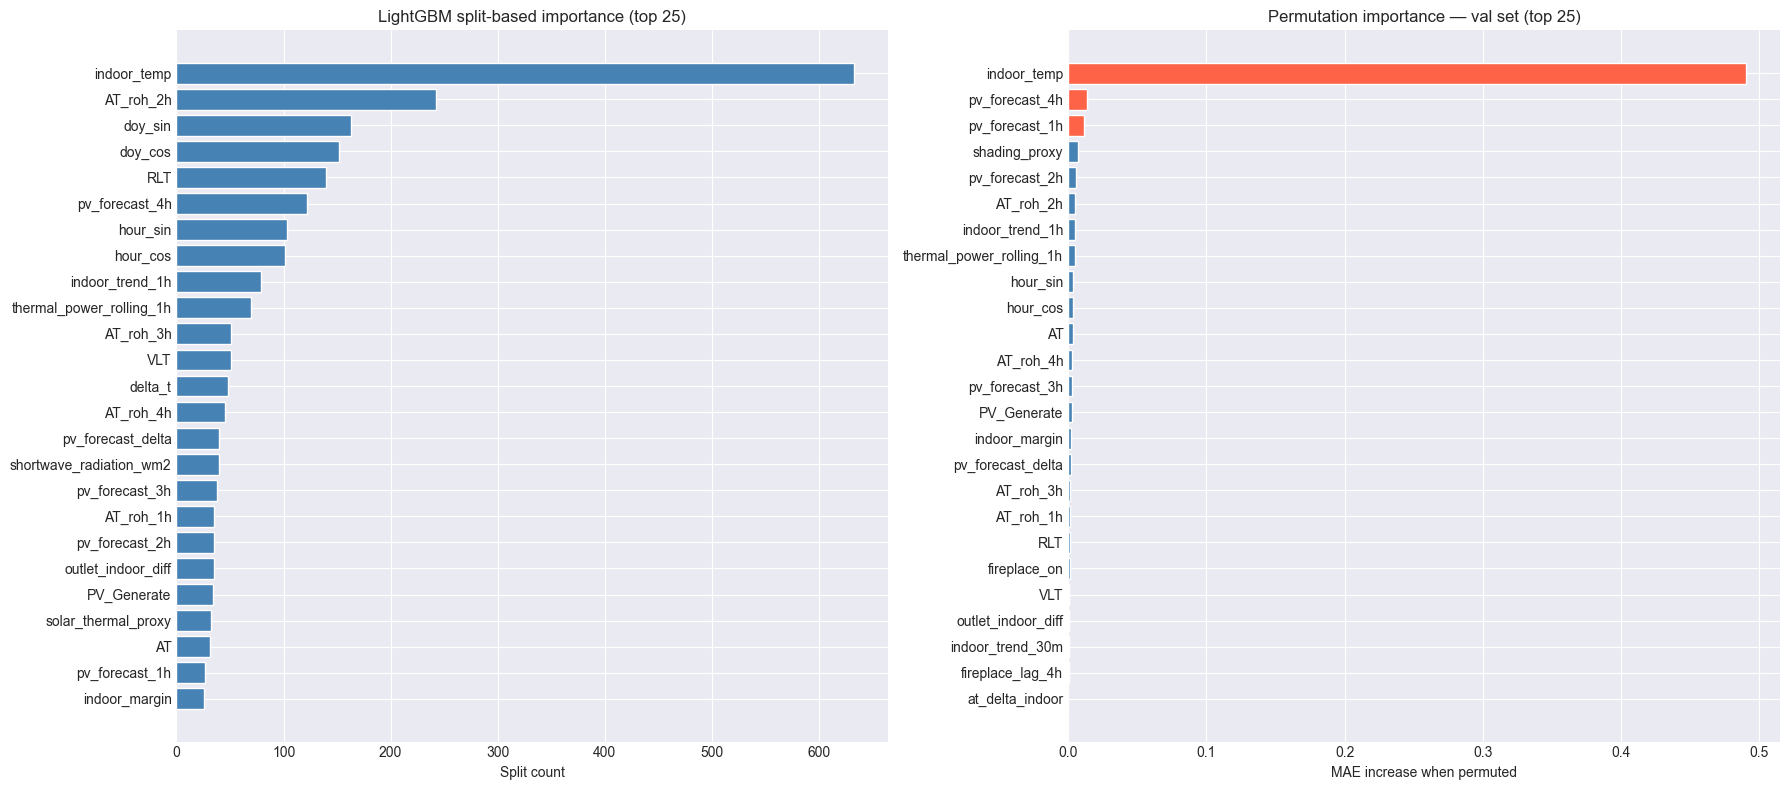

In [13]:
# ── Feature importance plots ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Split-based importance
names_fi = [x[0] for x in fi_sorted[:25]]
vals_fi = [x[1] for x in fi_sorted[:25]]
axes[0].barh(names_fi[::-1], vals_fi[::-1], color="steelblue", edgecolor="white")
axes[0].set_xlabel("Split count")
axes[0].set_title("LightGBM split-based importance (top 25)")

# Permutation importance
names_pi = [x[0] for x in pi_sorted[:25]]
vals_pi = [x[1] for x in pi_sorted[:25]]
colors = ["tomato" if v > 0.01 else "steelblue" if v > 0 else "lightgrey" for v in vals_pi]
axes[1].barh(names_pi[::-1], vals_pi[::-1], color=colors[::-1], edgecolor="white")
axes[1].set_xlabel("MAE increase when permuted")
axes[1].set_title("Permutation importance — val set (top 25)")

plt.tight_layout()
plt.show()

## 6. Time-Series Cross-Validation

In [14]:
N_CV_FOLDS = 5

tscv = TimeSeriesSplit(n_splits=N_CV_FOLDS)
cv_maes = []
cv_r2s = []

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X)):
    m_cv = lgb.LGBMRegressor(**LGB_PARAMS)
    m_cv.fit(
        X[tr_idx], y[tr_idx],
        eval_set=[(X[val_idx], y[val_idx])],
        eval_metric="mae",
        callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(0)],
    )
    yp = m_cv.predict(X[val_idx])
    fold_mae = mean_absolute_error(y[val_idx], yp)
    fold_r2 = r2_score(y[val_idx], yp)
    cv_maes.append(fold_mae)
    cv_r2s.append(fold_r2)
    print(f"  Fold {fold+1}: MAE={fold_mae:.4f}  R²={fold_r2:.4f}")

print(f"\n=== TIME-SERIES CV ({N_CV_FOLDS}-fold) ===  "
      f"MAE={np.mean(cv_maes):.4f}±{np.std(cv_maes):.4f}  "
      f"R²={np.mean(cv_r2s):.4f}±{np.std(cv_r2s):.4f}")

c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  Fold 1: MAE=0.1696  R²=0.8504
  Fold 2: MAE=0.1556  R²=0.8201


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  Fold 3: MAE=0.1341  R²=0.7603


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  Fold 4: MAE=0.1252  R²=0.8134
  Fold 5: MAE=0.1532  R²=0.8540

=== TIME-SERIES CV (5-fold) ===  MAE=0.1475±0.0159  R²=0.8196±0.0337


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 7. Optuna Hyperparameter Optimization (Optional)

Set `RUN_OPTUNA = True` to re-tune hyperparameters. Uses 3-fold time-series CV on the training pool only.

In [15]:
RUN_OPTUNA = True   # ← set to True to run HPO
N_OPTUNA_TRIALS = 50

if RUN_OPTUNA and USE_OPTUNA:
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    def objective(trial):
        params = {
            "objective": "regression_l1",
            "metric": "mae",
            "n_estimators": 300,
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
            "max_depth": trial.suggest_int("max_depth", 3, 8),
            "num_leaves": trial.suggest_int("num_leaves", 15, 63),
            "min_child_samples": trial.suggest_int("min_child_samples", 10, 60),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
            "random_state": 42,
            "n_jobs": -1,
            "verbose": -1,
        }
        tscv_opt = TimeSeriesSplit(n_splits=3)
        fold_maes = []
        for tr_i, val_i in tscv_opt.split(X_train):
            m = lgb.LGBMRegressor(**params)
            m.fit(
                X_train[tr_i], y_train[tr_i],
                eval_set=[(X_train[val_i], y_train[val_i])],
                eval_metric="mae",
                callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(0)],
            )
            fold_maes.append(mean_absolute_error(y_train[val_i], m.predict(X_train[val_i])))
        return np.mean(fold_maes)

    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)

    print(f"\n=== OPTUNA BEST PARAMS (n_trials={N_OPTUNA_TRIALS}, best_mae={study.best_value:.4f}) ===")
    for k, v in study.best_params.items():
        print(f"  {k:30s} {v}")

    # Retrain with best params
    best_params = {**LGB_PARAMS, **study.best_params}
    model_opt = lgb.LGBMRegressor(**best_params)
    model_opt.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="mae",
        callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(0)],
    )
    y_pred_opt = model_opt.predict(X_val)
    opt_mae = mean_absolute_error(y_val, y_pred_opt)
    opt_r2 = r2_score(y_val, y_pred_opt)
    print(f"\nOptuna-tuned Val MAE={opt_mae:.4f}°C, Val R²={opt_r2:.4f}")
    print(f"Baseline      Val MAE={val_mae:.4f}°C, Val R²={val_r2:.4f}")
elif RUN_OPTUNA and not USE_OPTUNA:
    print("⚠️  Optuna not installed — skipping HPO")
else:
    print("Optuna HPO skipped (set RUN_OPTUNA = True to enable)")

  0%|          | 0/50 [00:00<?, ?it/s]

c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid 


=== OPTUNA BEST PARAMS (n_trials=50, best_mae=0.1444) ===
  learning_rate                  0.07172812328304415
  max_depth                      4
  num_leaves                     30
  min_child_samples              33
  reg_alpha                      0.03882549001674052
  reg_lambda                     0.0025996262052871114

Optuna-tuned Val MAE=0.1431°C, Val R²=0.8631
Baseline      Val MAE=0.1448°C, Val R²=0.8652


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 8. Comparison with HA Baseline

In [16]:
# ── Side-by-side comparison ───────────────────────────────────────────────────
print("┌─────────────────────────────────────────────────────────────────┐")
print("│             Metric Comparison: Notebook vs HA Baseline         │")
print("├──────────────────┬──────────────┬──────────────────────────────┤")
print("│ Metric           │ Notebook     │ HA_LOG (May 20, pruned)      │")
print("├──────────────────┼──────────────┼──────────────────────────────┤")
print(f"│ Val MAE          │ {val_mae:>10.4f}°C │ 0.1404°C                     │")
print(f"│ Val R²           │ {val_r2:>12.4f} │ 0.8702                       │")
print(f"│ Features         │ {len(FEATURE_COLS):>12d} │ 34 (pruned from 51)          │")
print(f"│ Training rows    │ {len(X_train):>12,} │ 85,078                       │")
if baseline_meta:
    print("├──────────────────┼──────────────┼──────────────────────────────┤")
    print(f"│ metadata.json    │              │ MAE={baseline_meta.get('val_mae', 0):.4f}  R²={baseline_meta.get('val_r2', 0):.4f}  │")
print("└──────────────────┴──────────────┴──────────────────────────────┘")

┌─────────────────────────────────────────────────────────────────┐
│             Metric Comparison: Notebook vs HA Baseline         │
├──────────────────┬──────────────┬──────────────────────────────┤
│ Metric           │ Notebook     │ HA_LOG (May 20, pruned)      │
├──────────────────┼──────────────┼──────────────────────────────┤
│ Val MAE          │     0.1448°C │ 0.1404°C                     │
│ Val R²           │       0.8652 │ 0.8702                       │
│ Features         │           52 │ 34 (pruned from 51)          │
│ Training rows    │       63,808 │ 85,078                       │
├──────────────────┼──────────────┼──────────────────────────────┤
│ metadata.json    │              │ MAE=0.1466  R²=0.8611  │
└──────────────────┴──────────────┴──────────────────────────────┘


---
## 9. Feature Ablation — Leave-One-Out

For each feature: retrain without it and measure MAE / R² change.

In [17]:
print(f"Running leave-one-out ablation for {len(FEATURE_COLS)} features…\n")

ablation_results = []
for i, feat in enumerate(FEATURE_COLS):
    remaining = [f for f in FEATURE_COLS if f != feat]
    r_idx = [FEATURE_COLS.index(f) for f in remaining]
    X_tr_ab = X_train[:, r_idx]
    X_val_ab = X_val[:, r_idx]

    m_ab = lgb.LGBMRegressor(**LGB_PARAMS)
    m_ab.fit(
        X_tr_ab, y_train,
        eval_set=[(X_val_ab, y_val)],
        eval_metric="mae",
        callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(0)],
    )
    yp_ab = m_ab.predict(X_val_ab)
    ab_mae = mean_absolute_error(y_val, yp_ab)
    ab_r2 = r2_score(y_val, yp_ab)

    ablation_results.append({
        "feature": feat,
        "mae_without": ab_mae,
        "r2_without": ab_r2,
        "mae_delta": ab_mae - val_mae,
        "r2_delta": ab_r2 - val_r2,
    })
    marker = "🔴" if ab_mae - val_mae > 0.005 else "🟡" if ab_mae - val_mae > 0.001 else "⚪"
    print(f"  {marker} {i+1:2d}/{len(FEATURE_COLS)} removed {feat:35s} → MAE={ab_mae:.4f} (Δ{ab_mae - val_mae:+.4f})  R²={ab_r2:.4f} (Δ{ab_r2 - val_r2:+.4f})")

ab_df = pd.DataFrame(ablation_results).sort_values("mae_delta", ascending=False)
print("\n=== LEAVE-ONE-OUT ABLATION RANKING (sorted by MAE increase) ===")
for _, row in ab_df.iterrows():
    print(f"  {row['feature']:35s}  MAE Δ={row['mae_delta']:+.4f}   R² Δ={row['r2_delta']:+.4f}")

Running leave-one-out ablation for 52 features…



c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  ⚪  1/52 removed indoor_temp                         → MAE=0.1432 (Δ-0.0016)  R²=0.8686 (Δ+0.0034)


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  ⚪  2/52 removed indoor_margin                       → MAE=0.1443 (Δ-0.0005)  R²=0.8647 (Δ-0.0006)


...

c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  🟡 50/52 removed hour_cos                            → MAE=0.1487 (Δ+0.0039)  R²=0.8514 (Δ-0.0139)


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  🟡 51/52 removed doy_sin                             → MAE=0.1473 (Δ+0.0025)  R²=0.8570 (Δ-0.0082)
  🟡 52/52 removed doy_cos                             → MAE=0.1479 (Δ+0.0031)  R²=0.8551 (Δ-0.0101)

=== LEAVE-ONE-OUT ABLATION RANKING (sorted by MAE increase) ===
  AT_roh_1h                            MAE Δ=+0.0095   R² Δ=-0.0289
  hour_cos                             MAE Δ=+0.0039   R² Δ=-0.0139
  thermal_power_rolling_1h             MAE Δ=+0.0038   R² Δ=-0.0111
  fireplace_lag_2h                     MAE Δ=+0.0031   R² Δ=-0.0104
  doy_cos                              MAE Δ=+0.0031   R² Δ=-0.0101
  pv_roll_1h                           MAE Δ=+0.0027   R² Δ=-0.0153
  doy_sin                              MAE Δ=+0.0025   R² Δ=-0.0082
  fireplace_on                         MAE Δ=+0.0024   R² Δ=-0.0127
  shortwave_radiation_wm2              MAE Δ=+0.0021   R² Δ=-0.0091
  hour_sin                             MAE Δ=+0.0020   R² Δ=-0.0083
  pv_forecast_4h                       MAE Δ=+0.0014   

c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


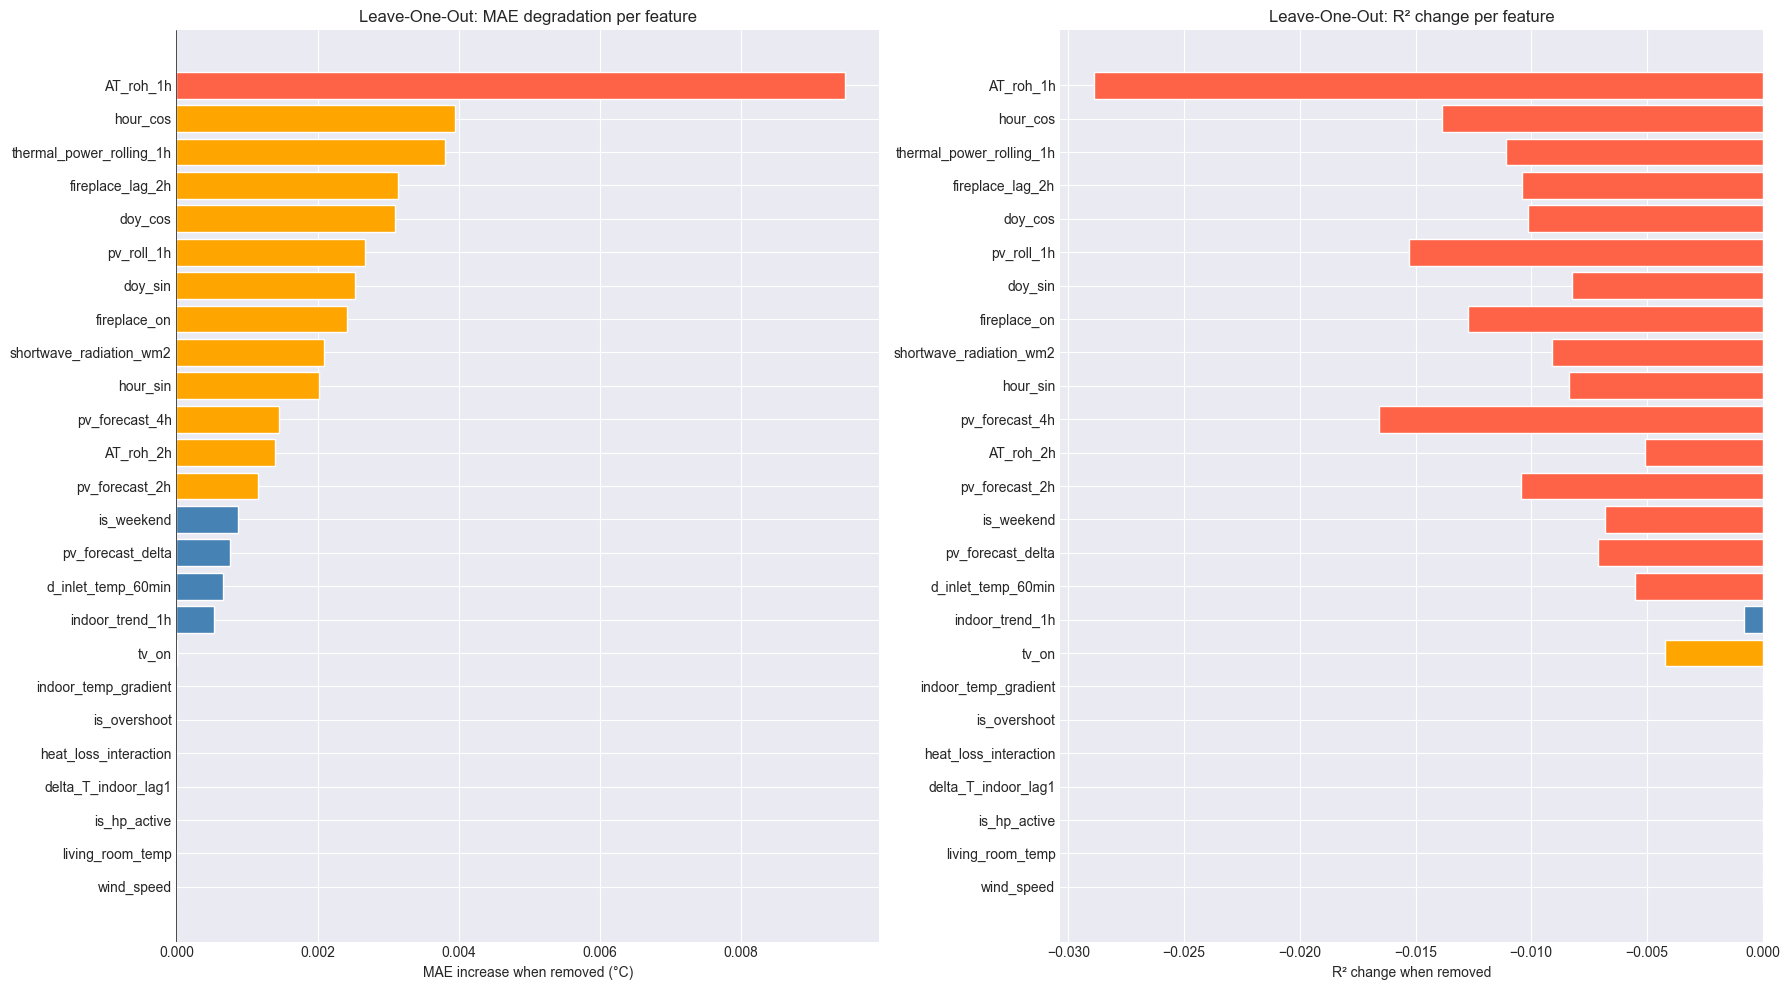

In [18]:
# ── Leave-one-out ablation plot ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# MAE increase when feature removed (top 25)
ab_top = ab_df.head(25)
colors = ["tomato" if d > 0.005 else "orange" if d > 0.001 else "steelblue" for d in ab_top["mae_delta"]]
axes[0].barh(ab_top["feature"].values[::-1], ab_top["mae_delta"].values[::-1],
             color=colors[::-1], edgecolor="white")
axes[0].axvline(0, color="black", linewidth=0.5)
axes[0].set_xlabel("MAE increase when removed (°C)")
axes[0].set_title("Leave-One-Out: MAE degradation per feature")

# R² change when feature removed
axes[1].barh(ab_top["feature"].values[::-1], ab_top["r2_delta"].values[::-1],
             color=["tomato" if d < -0.005 else "orange" if d < -0.001 else "steelblue" for d in ab_top["r2_delta"].values[::-1]],
             edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.5)
axes[1].set_xlabel("R² change when removed")
axes[1].set_title("Leave-One-Out: R² change per feature")

plt.tight_layout()
plt.show()

## 10. Feature Group Ablation

Remove entire feature groups at once to measure their collective contribution.

In [19]:
FEATURE_GROUPS = {
    "Indoor state": ["indoor_temp", "indoor_margin", "indoor_trend_30m", "indoor_trend_1h",
                     "indoor_temp_gradient", "indoor_margin_rate", "is_overshoot"],
    "Outdoor / forecasts": ["AT", "at_delta_indoor", "AT_roh_1h", "AT_roh_2h", "AT_roh_3h", "AT_roh_4h"],
    "PV / Solar": ["PV_Generate", "pv_roll_1h", "pv_roll_2h", "pv_forecast_1h", "pv_forecast_2h",
                   "pv_forecast_3h", "pv_forecast_4h", "pv_forecast_delta",
                   "solar_thermal_proxy", "shading_proxy", "shortwave_radiation_wm2"],
    "HP thermal": ["VLT", "RLT", "delta_t", "outlet_indoor_diff", "thermal_power_w",
                   "thermal_power_rolling_1h", "Q_wp"],
    "External heat": ["fireplace_on", "fireplace_lag_1h", "fireplace_lag_2h",
                      "fireplace_lag_3h", "fireplace_lag_4h", "tv_on", "tv_lag_30m", "tv_lag_1h"],
    "Slab state": ["d_inlet_temp_60min", "is_equilibrium"],
    "Context / wind": ["wind_speed", "living_room_temp", "is_hp_active", "is_weekend",
                       "heat_loss_driving_force", "delta_T_indoor_lag1", "heat_loss_interaction"],
    "Cyclical time": ["hour_sin", "hour_cos", "doy_sin", "doy_cos"],
}

group_results = []
for group_name, group_feats in FEATURE_GROUPS.items():
    active_in_group = [f for f in group_feats if f in FEATURE_COLS]
    remaining = [f for f in FEATURE_COLS if f not in active_in_group]
    if not remaining or not active_in_group:
        continue
    r_idx = [FEATURE_COLS.index(f) for f in remaining]
    X_tr_g = X_train[:, r_idx]
    X_val_g = X_val[:, r_idx]

    m_g = lgb.LGBMRegressor(**LGB_PARAMS)
    m_g.fit(
        X_tr_g, y_train,
        eval_set=[(X_val_g, y_val)],
        eval_metric="mae",
        callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(0)],
    )
    yp_g = m_g.predict(X_val_g)
    g_mae = mean_absolute_error(y_val, yp_g)
    g_r2 = r2_score(y_val, yp_g)

    group_results.append({
        "group": group_name,
        "n_features": len(active_in_group),
        "mae_without": g_mae,
        "r2_without": g_r2,
        "mae_delta": g_mae - val_mae,
        "r2_delta": g_r2 - val_r2,
    })
    marker = "🔴" if g_mae - val_mae > 0.01 else "🟡" if g_mae - val_mae > 0.003 else "⚪"
    print(f"  {marker} Without '{group_name}' ({len(active_in_group)}f): "
          f"MAE={g_mae:.4f} (Δ{g_mae - val_mae:+.4f})  R²={g_r2:.4f} (Δ{g_r2 - val_r2:+.4f})")

grp_df = pd.DataFrame(group_results)
grp_sorted = grp_df.sort_values("mae_delta", ascending=False)
print("\n=== GROUP ABLATION RANKING ===")
for _, row in grp_sorted.iterrows():
    print(f"  {row['group']:25s} ({row['n_features']:.0f}f)  MAE Δ={row['mae_delta']:+.4f}  R² Δ={row['r2_delta']:+.4f}")

c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  🔴 Without 'Indoor state' (7f): MAE=0.1566 (Δ+0.0118)  R²=0.8314 (Δ-0.0338)


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  ⚪ Without 'Outdoor / forecasts' (6f): MAE=0.1441 (Δ-0.0007)  R²=0.8560 (Δ-0.0093)


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


...

c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  ⚪ Without 'Slab state' (2f): MAE=0.1455 (Δ+0.0007)  R²=0.8597 (Δ-0.0055)


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  ⚪ Without 'Context / wind' (7f): MAE=0.1459 (Δ+0.0011)  R²=0.8537 (Δ-0.0115)
  🔴 Without 'Cyclical time' (4f): MAE=0.1572 (Δ+0.0124)  R²=0.8421 (Δ-0.0231)

=== GROUP ABLATION RANKING ===
  Cyclical time             (4f)  MAE Δ=+0.0124  R² Δ=-0.0231
  Indoor state              (7f)  MAE Δ=+0.0118  R² Δ=-0.0338
  PV / Solar                (11f)  MAE Δ=+0.0096  R² Δ=-0.0220
  Context / wind            (7f)  MAE Δ=+0.0011  R² Δ=-0.0115
  Slab state                (2f)  MAE Δ=+0.0007  R² Δ=-0.0055
  HP thermal                (7f)  MAE Δ=-0.0005  R² Δ=+0.0007
  Outdoor / forecasts       (6f)  MAE Δ=-0.0007  R² Δ=-0.0093
  External heat             (8f)  MAE Δ=-0.0012  R² Δ=-0.0058


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


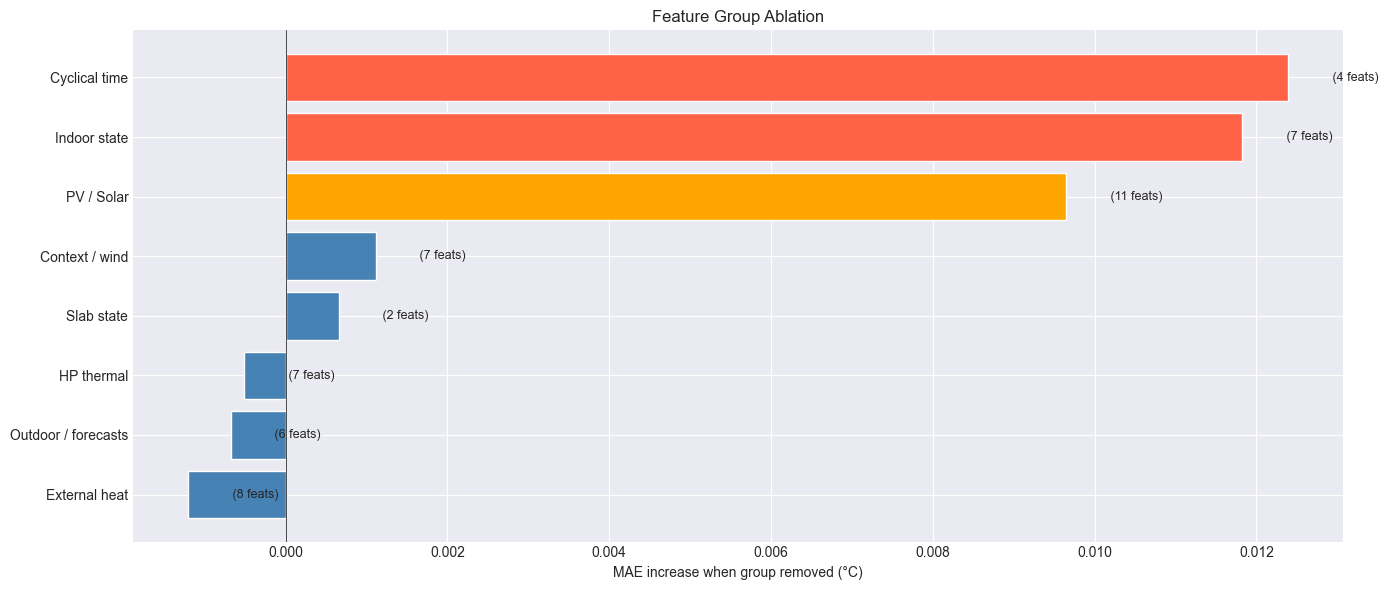

In [21]:
# ── Group ablation plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

grp_sorted = grp_df.sort_values("mae_delta", ascending=True)
colors = ["tomato" if d > 0.01 else "orange" if d > 0.002 else "steelblue"
          for d in grp_sorted["mae_delta"]]
bars = ax.barh(grp_sorted["group"], grp_sorted["mae_delta"], color=colors, edgecolor="white")

# Annotate with n_features
for bar, n in zip(bars, grp_sorted["n_features"]):
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
            f" ({n:.0f} feats)", va="center", fontsize=9)

ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("MAE increase when group removed (°C)")
ax.set_title("Feature Group Ablation")
plt.tight_layout()
plt.show()

---
## 11. `indoor_temp` Dominance Diagnosis

### Why does `indoor_temp` have permutation importance of 0.4956 while everything else is < 0.01?

**Root cause:** The label is `label[t] = -(T_indoor[t + N] - T_target) / S_H`.
Due to the building's thermal inertia, `T_indoor[t+N]` is highly correlated with `T_indoor[t]`.
This means `indoor_temp` is essentially a direct proxy for the label magnitude.
The model learns: *"if current temp is far from target, predict large correction"* — which
is trivially correct but **buries the signal from other features**.

When `indoor_temp` dominates, permutation importance of correlated features
(AT forecasts, PV, trends) appears artificially low because shuffling them barely
hurts — `indoor_temp` compensates.

=== FEATURE CORRELATION WITH LABEL (|Pearson r|) ===
  ★ indoor_margin                       r=0.8386
  ★ indoor_temp                         r=0.8386
  ★ living_room_temp                    r=0.8386
  ★ is_overshoot                        r=0.5123
  ● shading_proxy                       r=0.3528
  ● AT                                  r=0.2919
  ● AT_roh_1h                           r=0.2834
  ● AT_roh_2h                           r=0.2710
  ● outlet_indoor_diff                  r=0.2666
  ● hour_sin                            r=0.2611
  ● AT_roh_3h                           r=0.2546
  ● at_delta_indoor                     r=0.2503
  ● heat_loss_driving_force             r=0.2503
  ● AT_roh_4h                           r=0.2340
  ● is_hp_active                        r=0.2252
  ● thermal_power_rolling_1h            r=0.2210
  ● thermal_power_w                     r=0.2076
  ● Q_wp                                r=0.2076
  ● delta_t                             r=0.2068
  ● VLT         

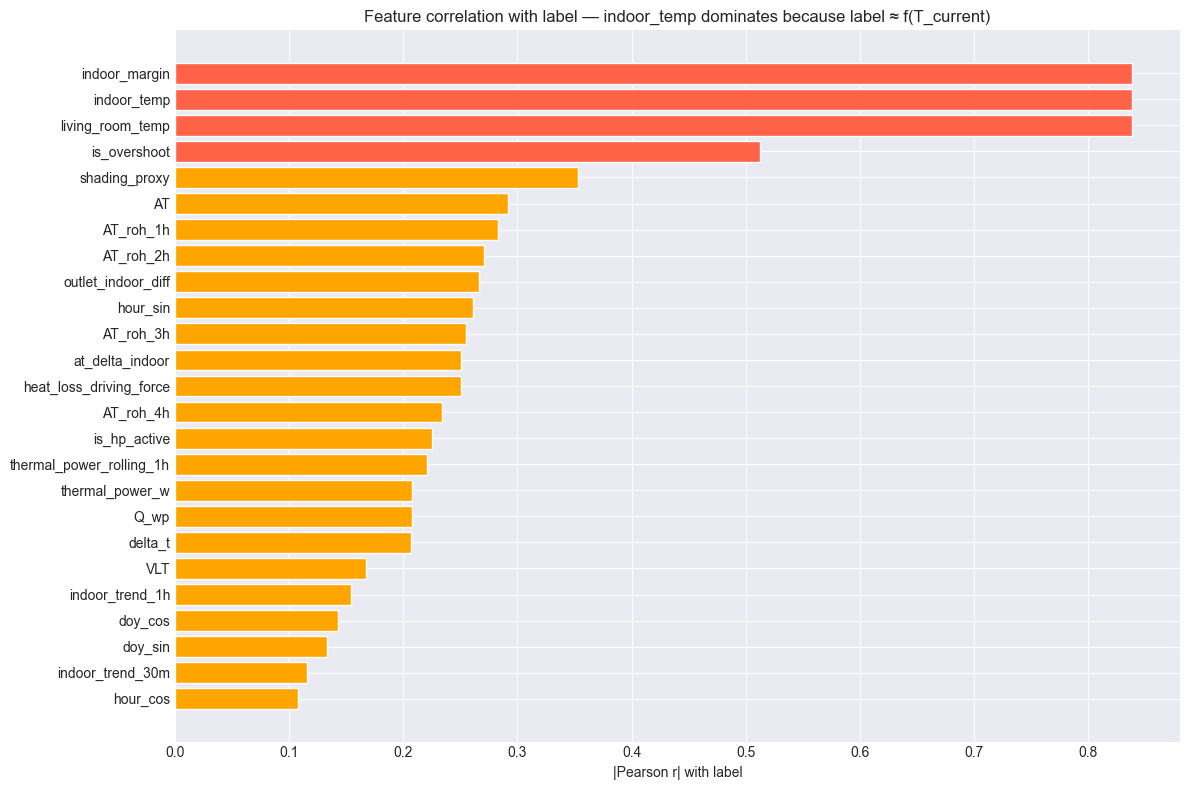

In [22]:
# ── 11a. Correlation of each feature with label ──────────────────────────────
corr_with_label = model_df[FEATURE_COLS + ["label"]].corr()["label"].drop("label").abs().sort_values(ascending=False)

print("=== FEATURE CORRELATION WITH LABEL (|Pearson r|) ===")
for feat, corr in corr_with_label.items():
    marker = "★" if corr > 0.5 else "●" if corr > 0.1 else "○"
    print(f"  {marker} {feat:35s} r={corr:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
top_corr = corr_with_label.head(25)
colors = ["tomato" if v > 0.5 else "orange" if v > 0.1 else "steelblue" for v in top_corr]
ax.barh(top_corr.index[::-1], top_corr.values[::-1], color=colors[::-1], edgecolor="white")
ax.set_xlabel("|Pearson r| with label")
ax.set_title("Feature correlation with label — indoor_temp dominates because label ≈ f(T_current)")
plt.tight_layout()
plt.show()

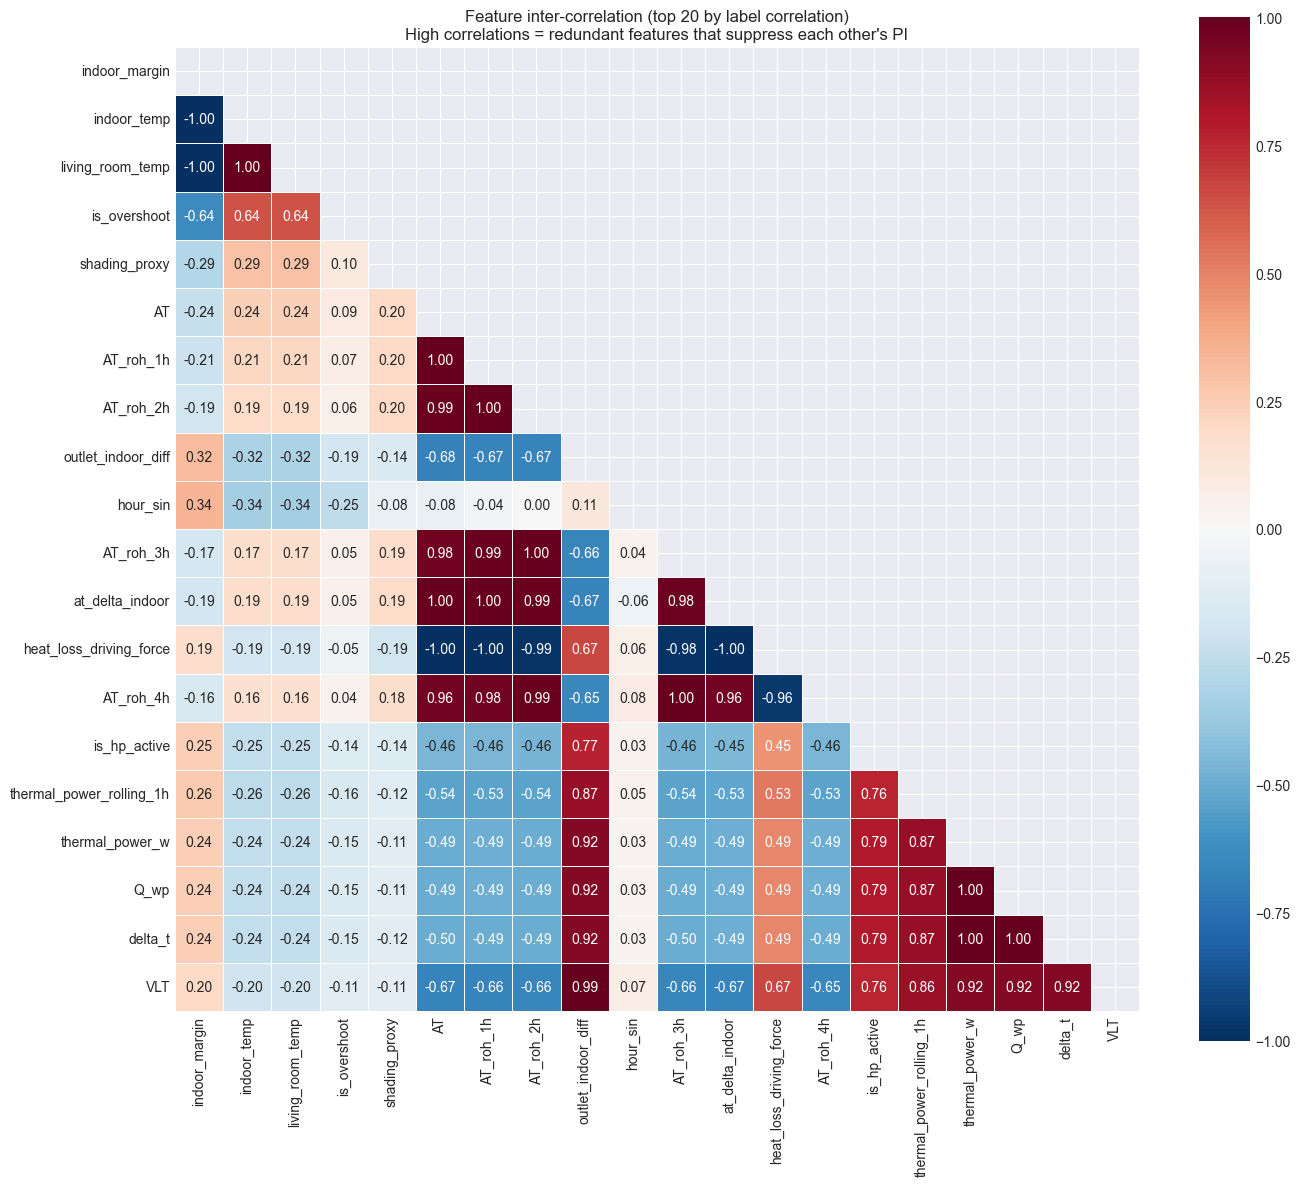


=== STRONGLY CORRELATED FEATURE PAIRS (|r| > 0.8) ===
  indoor_margin                  ↔ indoor_temp                     r=-1.000
  indoor_margin                  ↔ living_room_temp                r=-1.000
  indoor_temp                    ↔ living_room_temp                r=+1.000
  AT                             ↔ AT_roh_1h                       r=+0.996
  AT                             ↔ AT_roh_2h                       r=+0.987
  AT                             ↔ AT_roh_3h                       r=+0.976
  AT                             ↔ at_delta_indoor                 r=+0.999
  AT                             ↔ heat_loss_driving_force         r=-0.999
  AT                             ↔ AT_roh_4h                       r=+0.962
  AT_roh_1h                      ↔ AT_roh_2h                       r=+0.996
  AT_roh_1h                      ↔ AT_roh_3h                       r=+0.987
  AT_roh_1h                      ↔ at_delta_indoor                 r=+0.995
  AT_roh_1h                      

In [23]:
# ── 11b. Feature inter-correlation heatmap (top 20 by label correlation) ──────
top20 = corr_with_label.head(20).index.tolist()
corr_matrix = model_df[top20].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=ax, square=True, linewidths=0.5)
ax.set_title("Feature inter-correlation (top 20 by label correlation)\n"
             "High correlations = redundant features that suppress each other's PI")
plt.tight_layout()
plt.show()

# Identify strongly correlated pairs
print("\n=== STRONGLY CORRELATED FEATURE PAIRS (|r| > 0.8) ===")
for i in range(len(top20)):
    for j in range(i+1, len(top20)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.8:
            print(f"  {top20[i]:30s} ↔ {top20[j]:30s}  r={r:+.3f}")

### 11c. Label Leakage / Dominance Experiment

Test whether `indoor_margin` (= indoor_temp − target) captures the same signal as `indoor_temp`.
Then test what R² remains when we remove **both**.

In [24]:
experiments = {
    "Baseline (all features)": FEATURE_COLS,
    "Without indoor_temp": [f for f in FEATURE_COLS if f != "indoor_temp"],
    "Without indoor_margin": [f for f in FEATURE_COLS if f != "indoor_margin"],
    "Without BOTH indoor_temp & indoor_margin": [f for f in FEATURE_COLS
                                                 if f not in ("indoor_temp", "indoor_margin")],
    "Only indoor_temp": ["indoor_temp"],
    "Only indoor_margin": ["indoor_margin"],
    "Only indoor state group": [f for f in FEATURE_COLS if f in FEATURE_GROUPS.get("Indoor state", [])],
}

exp_results = []
for exp_name, exp_feats in experiments.items():
    exp_feats_valid = [f for f in exp_feats if f in FEATURE_COLS]
    if not exp_feats_valid:
        print(f"  ⚠️  {exp_name}: no valid features — skipping")
        continue

    e_idx = [FEATURE_COLS.index(f) for f in exp_feats_valid]
    X_tr_e = X_train[:, e_idx]
    X_val_e = X_val[:, e_idx]

    m_e = lgb.LGBMRegressor(**LGB_PARAMS)
    m_e.fit(
        X_tr_e, y_train,
        eval_set=[(X_val_e, y_val)],
        eval_metric="mae",
        callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(0)],
    )
    yp_e = m_e.predict(X_val_e)
    e_mae = mean_absolute_error(y_val, yp_e)
    e_r2 = r2_score(y_val, yp_e)

    exp_results.append({"experiment": exp_name, "n_features": len(exp_feats_valid),
                        "mae": e_mae, "r2": e_r2})
    print(f"  {exp_name:50s}  ({len(exp_feats_valid):2d} feats)  MAE={e_mae:.4f}  R²={e_r2:.4f}")

exp_df = pd.DataFrame(exp_results)

print("\n=== INDOOR_TEMP DOMINANCE EXPERIMENT SUMMARY ===")
print(exp_df.to_string(index=False))

c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  Baseline (all features)                             (52 feats)  MAE=0.1448  R²=0.8652


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  Without indoor_temp                                 (51 feats)  MAE=0.1432  R²=0.8686


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  Without indoor_margin                               (51 feats)  MAE=0.1443  R²=0.8647


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  Without BOTH indoor_temp & indoor_margin            (50 feats)  MAE=0.1443  R²=0.8647
  Only indoor_temp                                    ( 1 feats)  MAE=0.2058  R²=0.7615
  Only indoor_margin                                  ( 1 feats)  MAE=0.2060  R²=0.7607
  Only indoor state group                             ( 7 feats)  MAE=0.1714  R²=0.8102

=== INDOOR_TEMP DOMINANCE EXPERIMENT SUMMARY ===
                              experiment  n_features      mae       r2
                 Baseline (all features)          52 0.144790 0.865238
                     Without indoor_temp          51 0.143226 0.868617
                   Without indoor_margin          51 0.144270 0.864658
Without BOTH indoor_temp & indoor_margin          50 0.144270 0.864658
                        Only indoor_temp           1 0.205798 0.761521
                      Only indoor_margin           1 0.206027 0.760655
                 Only indoor state group           7 0.171448 0.810176


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


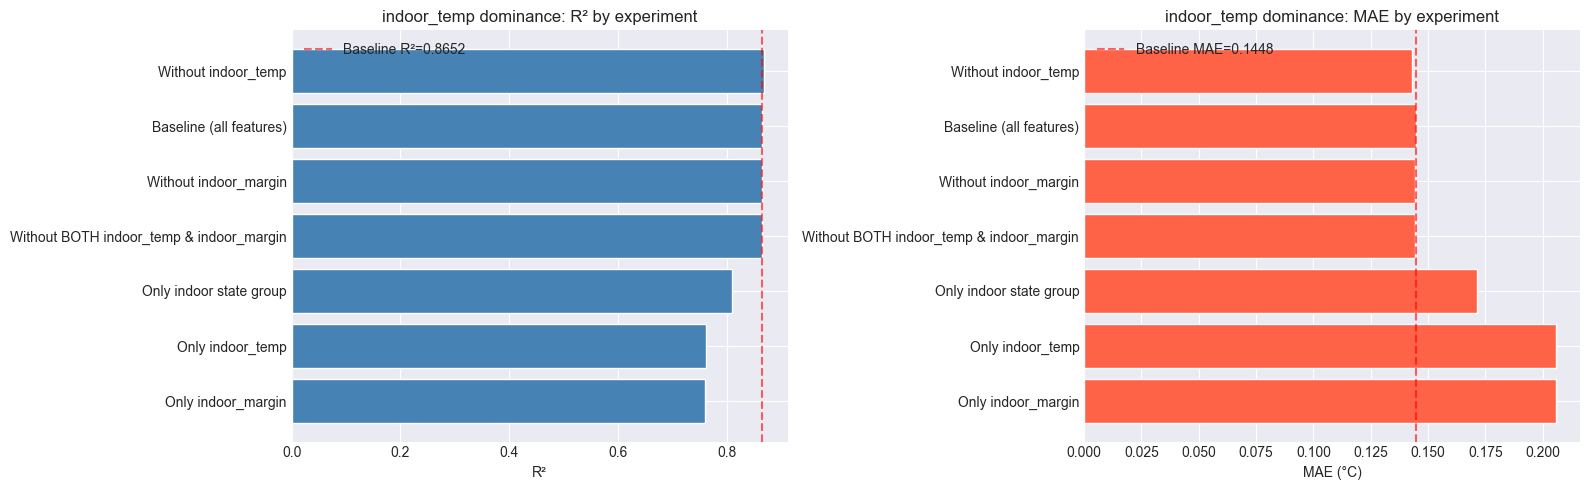

In [25]:
# ── Plot dominance experiment ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

exp_df_plot = exp_df.sort_values("r2", ascending=True)
axes[0].barh(exp_df_plot["experiment"], exp_df_plot["r2"], color="steelblue", edgecolor="white")
axes[0].axvline(val_r2, color="red", linestyle="--", alpha=0.6, label=f"Baseline R²={val_r2:.4f}")
axes[0].set_xlabel("R²")
axes[0].set_title("indoor_temp dominance: R² by experiment")
axes[0].legend()

axes[1].barh(exp_df_plot["experiment"], exp_df_plot["mae"], color="tomato", edgecolor="white")
axes[1].axvline(val_mae, color="red", linestyle="--", alpha=0.6, label=f"Baseline MAE={val_mae:.4f}")
axes[1].set_xlabel("MAE (°C)")
axes[1].set_title("indoor_temp dominance: MAE by experiment")
axes[1].legend()

plt.tight_layout()
plt.show()

### 11c-bis. Residualized Label Experiment

**Key insight:** Most of `indoor_temp`'s R² comes from the trivial relationship:
`label ≈ -indoor_margin / S_H`. We can subtract this trivial component to create
an **adjusted label** that captures only the perturbation (weather, PV, HP effects).

This reveals the *true* predictive power of the other features.

S_H estimate: 0.4920

Original label:  mean=-0.507  std=0.676
Adjusted label:  mean=-1.022  std=1.307


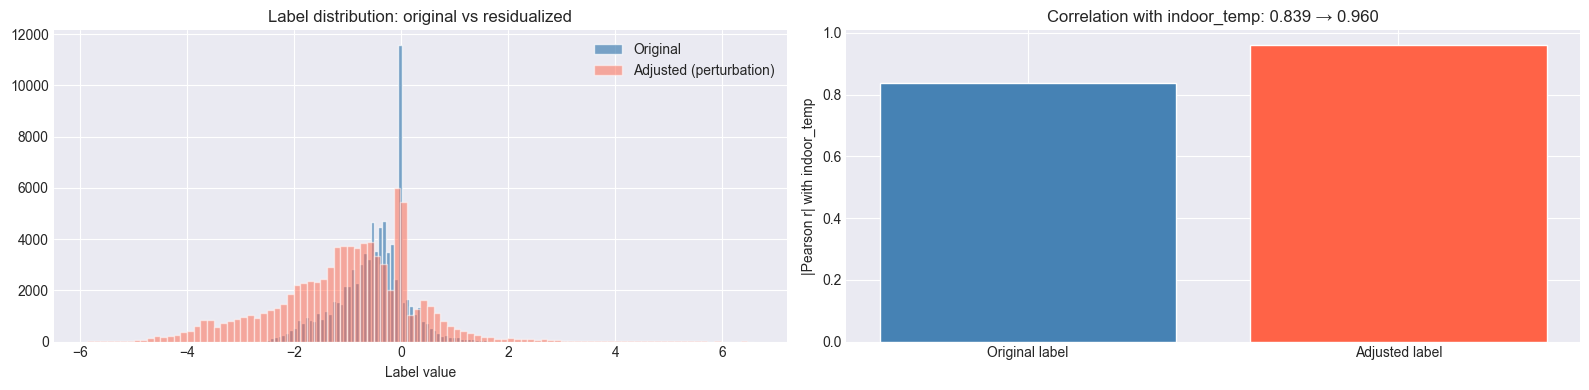


Training on adjusted label with 50 features (no indoor_temp/margin)…


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



=== RESIDUALIZED LABEL EXPERIMENT ===
  Original model (all features):          MAE=0.1448  R²=0.8652
  Adjusted label (no indoor_temp/margin):  MAE=0.1454  R²=0.9647

  → R² of 0.9647 = true predictive power of weather/PV/HP features
  → The remaining -0.0994 R² in the original model came from the
    trivial indoor_temp→label proxy (thermal inertia)

Computing permutation importance for residualized model…

=== PERMUTATION IMPORTANCE (residualized label, no indoor_temp) ===
  living_room_temp                        1.1827
  pv_forecast_4h                          0.0129
  hour_sin                                0.0077
  pv_forecast_2h                          0.0075
  pv_forecast_1h                          0.0068
  pv_forecast_3h                          0.0054
  hour_cos                                0.0053
  shading_proxy                           0.0048
  RLT                                     0.0047
  thermal_power_rolling_1h                0.0043
  indoor_trend_1h           

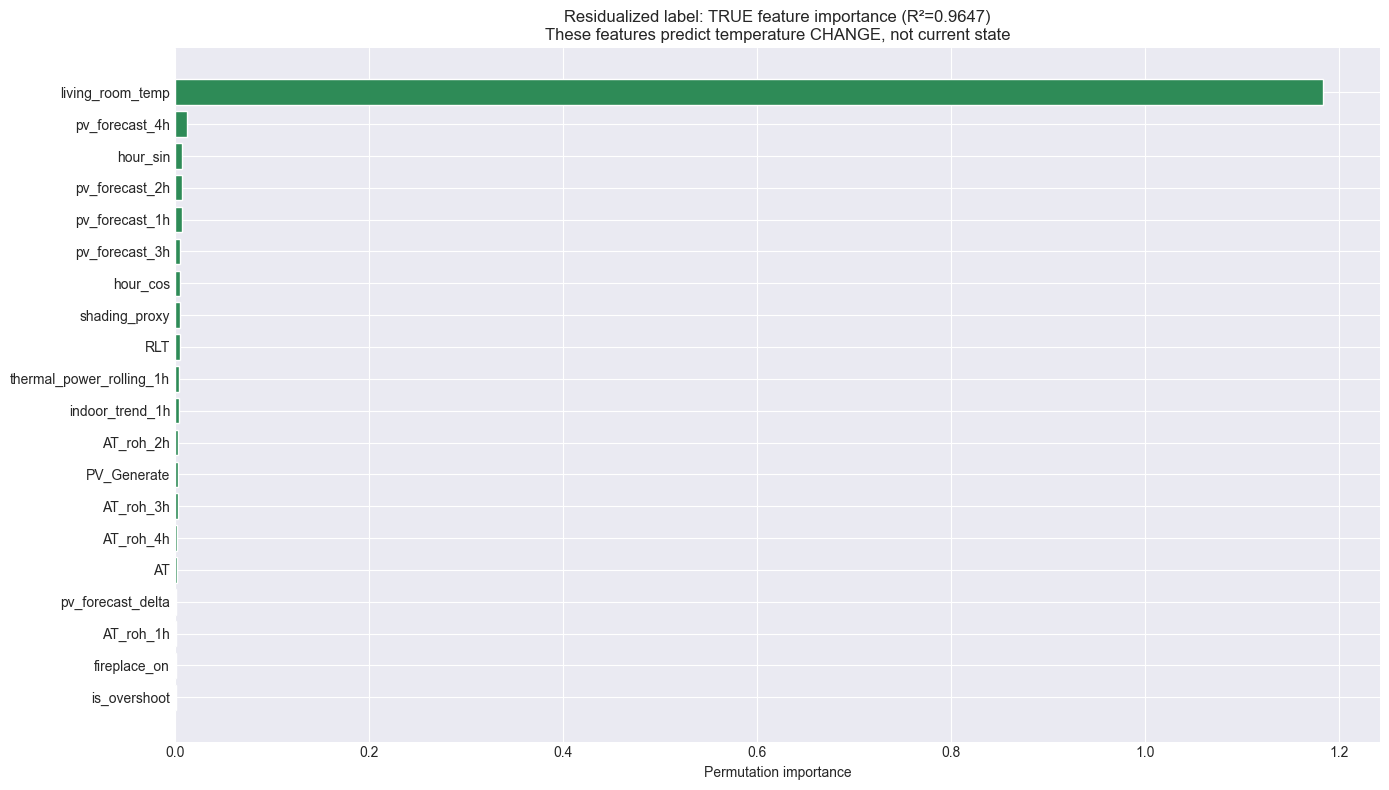

In [26]:
# ── Residualized label: subtract the trivial indoor_margin component ──────────
# The label is: -(T_future - T_target) / S_H
# Due to thermal inertia: T_future ≈ T_current + δ
# So: label ≈ -(indoor_temp - T_target) / S_H + δ/S_H = -indoor_margin/S_H + perturbation
#
# We subtract the trivial part to isolate the perturbation that weather/PV/HP cause.

S_H_EST = baseline_meta.get("s_h_estimated", 0.492) if baseline_meta else 0.492

# Adjusted label = original label + indoor_margin / S_H
# = -(T_future - T_target)/S_H + (indoor_temp - T_target)/S_H
# = -(T_future - indoor_temp)/S_H  ← pure temperature CHANGE over horizon
model_df_res = model_df.copy()
model_df_res["adjusted_label"] = model_df_res["label"] + model_df_res["indoor_margin"] / S_H_EST

print(f"S_H estimate: {S_H_EST:.4f}")
print(f"\nOriginal label:  mean={model_df_res['label'].mean():.3f}  std={model_df_res['label'].std():.3f}")
print(f"Adjusted label:  mean={model_df_res['adjusted_label'].mean():.3f}  std={model_df_res['adjusted_label'].std():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].hist(model_df_res["label"], bins=100, color="steelblue", edgecolor="white", alpha=0.7, label="Original")
axes[0].hist(model_df_res["adjusted_label"], bins=100, color="tomato", edgecolor="white", alpha=0.5, label="Adjusted (perturbation)")
axes[0].set_xlabel("Label value")
axes[0].set_title("Label distribution: original vs residualized")
axes[0].legend()

# Correlation of adjusted label with indoor_temp should be MUCH weaker
r_orig = model_df_res[["indoor_temp", "label"]].corr().iloc[0, 1]
r_adj = model_df_res[["indoor_temp", "adjusted_label"]].corr().iloc[0, 1]
axes[1].bar(["Original label", "Adjusted label"], [abs(r_orig), abs(r_adj)],
            color=["steelblue", "tomato"], edgecolor="white")
axes[1].set_ylabel("|Pearson r| with indoor_temp")
axes[1].set_title(f"Correlation with indoor_temp: {abs(r_orig):.3f} → {abs(r_adj):.3f}")
plt.tight_layout()
plt.show()

# ── Train on adjusted label WITHOUT indoor_temp and indoor_margin ─────────────
feats_residual = [f for f in FEATURE_COLS if f not in ("indoor_temp", "indoor_margin")]
print(f"\nTraining on adjusted label with {len(feats_residual)} features (no indoor_temp/margin)…")

y_adj = model_df_res["adjusted_label"].values
y_adj_train, y_adj_val = y_adj[:split_idx], y_adj[split_idx:]

r_idx = [FEATURE_COLS.index(f) for f in feats_residual]
X_tr_res = X_train[:, r_idx]
X_val_res = X_val[:, r_idx]

m_res = lgb.LGBMRegressor(**LGB_PARAMS)
m_res.fit(
    X_tr_res, y_adj_train,
    eval_set=[(X_val_res, y_adj_val)],
    eval_metric="mae",
    callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(0)],
)
yp_res = m_res.predict(X_val_res)
res_mae = mean_absolute_error(y_adj_val, yp_res)
res_r2 = r2_score(y_adj_val, yp_res)

print(f"\n=== RESIDUALIZED LABEL EXPERIMENT ===")
print(f"  Original model (all features):          MAE={val_mae:.4f}  R²={val_r2:.4f}")
print(f"  Adjusted label (no indoor_temp/margin):  MAE={res_mae:.4f}  R²={res_r2:.4f}")
print(f"\n  → R² of {res_r2:.4f} = true predictive power of weather/PV/HP features")
print(f"  → The remaining {val_r2 - res_r2:.4f} R² in the original model came from the")
print(f"    trivial indoor_temp→label proxy (thermal inertia)")

# Permutation importance on residualized model
print("\nComputing permutation importance for residualized model…")
perm_res = permutation_importance(
    m_res, X_val_res, y_adj_val,
    n_repeats=10, random_state=42,
    scoring="neg_mean_absolute_error", n_jobs=-1,
)
pi_res = dict(zip(feats_residual, perm_res.importances_mean))
pi_res_sorted = sorted(pi_res.items(), key=lambda x: x[1], reverse=True)

print("\n=== PERMUTATION IMPORTANCE (residualized label, no indoor_temp) ===")
for name, imp in pi_res_sorted[:25]:
    print(f"  {name:35s} {imp:>10.4f}")

# Plot
fig, ax = plt.subplots(figsize=(14, 8))
top_res = pi_res_sorted[:20]
ax.barh([x[0] for x in top_res][::-1], [x[1] for x in top_res][::-1],
        color="seagreen", edgecolor="white")
ax.set_xlabel("Permutation importance")
ax.set_title(f"Residualized label: TRUE feature importance (R²={res_r2:.4f})\n"
             f"These features predict temperature CHANGE, not current state")
plt.tight_layout()
plt.show()

### 11d. Feature Decorrelation: Re-rank importance after removing `indoor_temp`

When `indoor_temp` is removed, which features become important?
This reveals the "hidden" importance that was masked by the dominant predictor.

In [27]:
# ── Train model WITHOUT indoor_temp and re-compute permutation importance ─────
feats_no_it = [f for f in FEATURE_COLS if f != "indoor_temp"]
idx_no_it = [FEATURE_COLS.index(f) for f in feats_no_it]
X_tr_no_it = X_train[:, idx_no_it]
X_val_no_it = X_val[:, idx_no_it]

m_no_it = lgb.LGBMRegressor(**LGB_PARAMS)
m_no_it.fit(
    X_tr_no_it, y_train,
    eval_set=[(X_val_no_it, y_val)],
    eval_metric="mae",
    callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(0)],
)
y_pred_no_it = m_no_it.predict(X_val_no_it)
mae_no_it = mean_absolute_error(y_val, y_pred_no_it)
r2_no_it = r2_score(y_val, y_pred_no_it)
print(f"Model without indoor_temp: MAE={mae_no_it:.4f}  R²={r2_no_it:.4f}")

print("\nComputing permutation importance WITHOUT indoor_temp…")
perm_no_it = permutation_importance(
    m_no_it, X_val_no_it, y_val,
    n_repeats=10, random_state=42,
    scoring="neg_mean_absolute_error", n_jobs=-1,
)

pi_no_it = dict(zip(feats_no_it, perm_no_it.importances_mean))
pi_no_it_sorted = sorted(pi_no_it.items(), key=lambda x: x[1], reverse=True)

print("\n=== PERMUTATION IMPORTANCE (without indoor_temp) ===")
for name, imp in pi_no_it_sorted:
    # Show how ranking changed
    old_imp = pi.get(name, 0)
    change = "↑" if imp > old_imp + 0.001 else "↓" if imp < old_imp - 0.001 else "→"
    print(f"  {change} {name:35s} {imp:>10.4f}  (was {old_imp:.4f})")

c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Model without indoor_temp: MAE=0.1432  R²=0.8686

Computing permutation importance WITHOUT indoor_temp…

=== PERMUTATION IMPORTANCE (without indoor_temp) ===
  ↑ indoor_margin                           0.4937  (was 0.0019)
  ↓ pv_forecast_4h                          0.0125  (was 0.0138)
  → pv_forecast_1h                          0.0108  (was 0.0111)
  → shading_proxy                           0.0071  (was 0.0071)
  → thermal_power_rolling_1h                0.0049  (was 0.0046)
  ↑ PV_Generate                             0.0048  (was 0.0025)
  → indoor_trend_1h                         0.0046  (was 0.0049)
  → AT_roh_2h                               0.0045  (was 0.0050)
  ↑ pv_forecast_delta                       0.0042  (was 0.0016)
  → hour_cos                                0.0031  (was 0.0033)
  → hour_sin                                0.0030  (was 0.0036)
  → pv_forecast_3h                          0.0029  (was 0.0028)
  ↓ pv_forecast_2h                          0.0028  (was 0.005

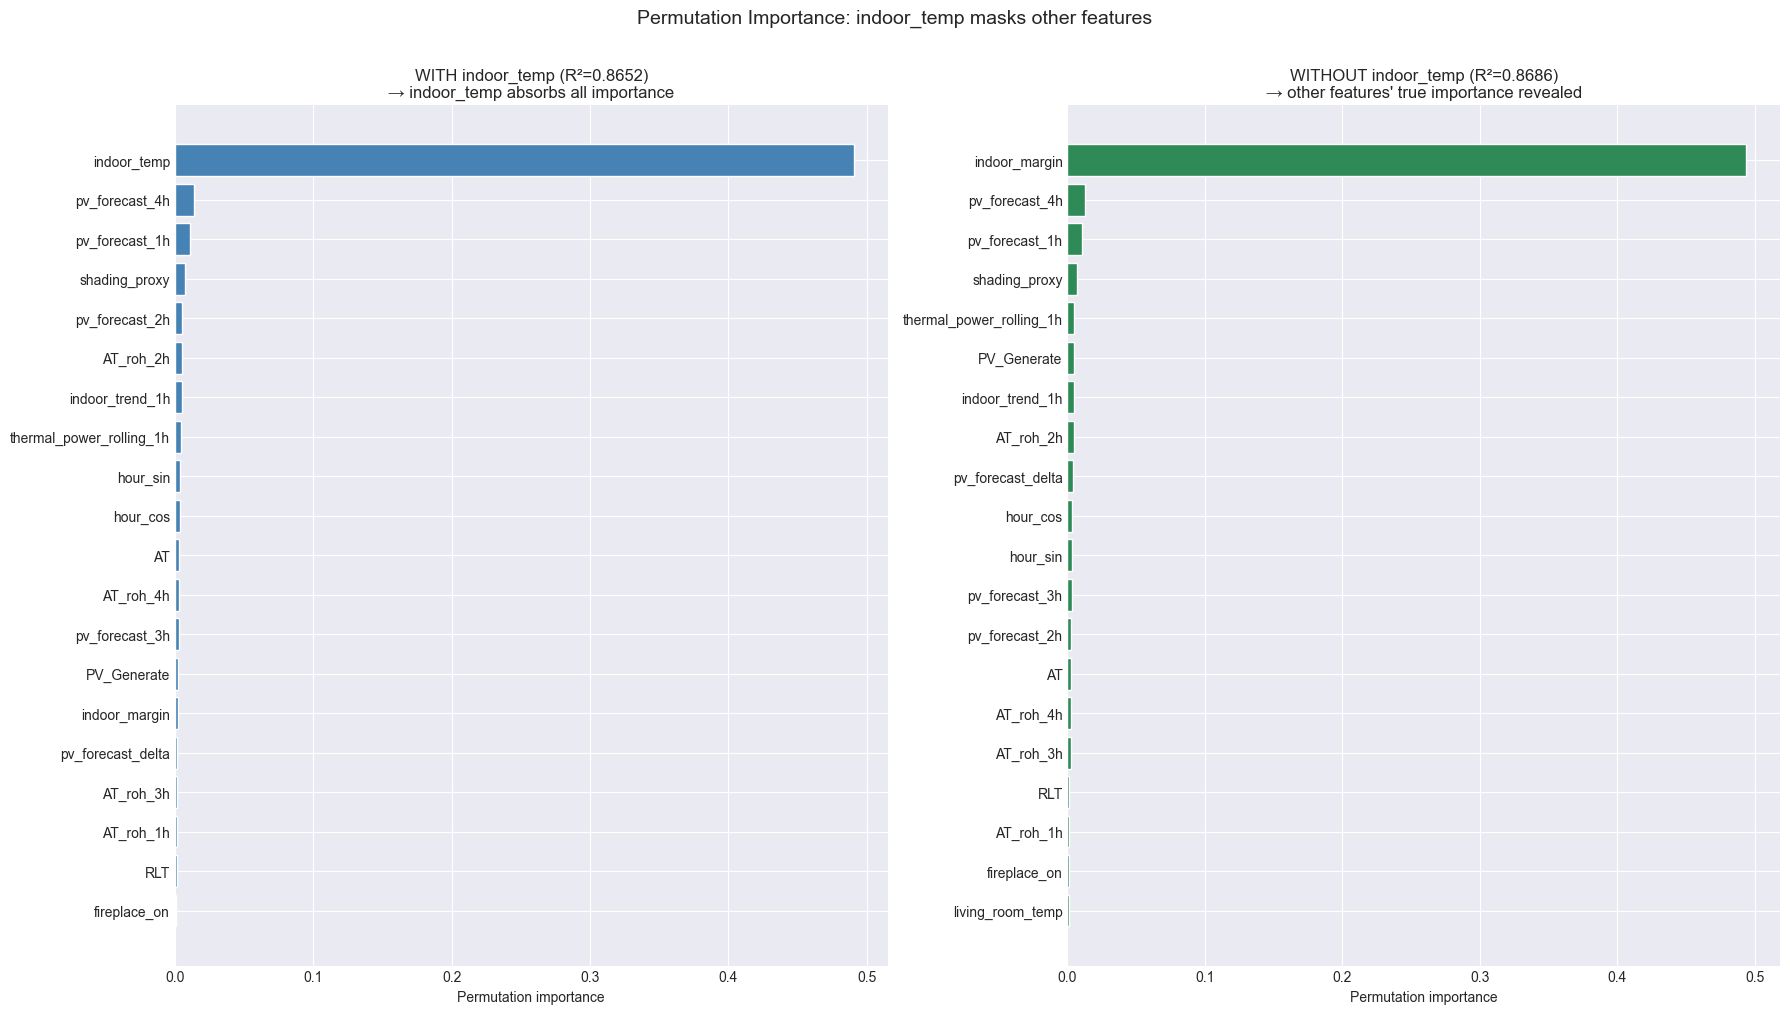

In [28]:
# ── Side-by-side PI comparison: with vs without indoor_temp ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# With indoor_temp (original)
top20_orig = pi_sorted[:20]
axes[0].barh([x[0] for x in top20_orig][::-1], [x[1] for x in top20_orig][::-1],
             color="steelblue", edgecolor="white")
axes[0].set_xlabel("Permutation importance")
axes[0].set_title(f"WITH indoor_temp (R²={val_r2:.4f})\n→ indoor_temp absorbs all importance")

# Without indoor_temp (decorrelated)
top20_no_it = pi_no_it_sorted[:20]
axes[1].barh([x[0] for x in top20_no_it][::-1], [x[1] for x in top20_no_it][::-1],
             color="seagreen", edgecolor="white")
axes[1].set_xlabel("Permutation importance")
axes[1].set_title(f"WITHOUT indoor_temp (R²={r2_no_it:.4f})\n→ other features' true importance revealed")

plt.suptitle("Permutation Importance: indoor_temp masks other features", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 12. Missing Feature Analysis — Residual Patterns

Analyse residuals to identify systematic patterns that suggest important missing features.

In [29]:
# ── Compute residuals on validation set ───────────────────────────────────────
residuals = y_val - y_pred
val_df = model_df.iloc[split_idx:].copy()
val_df = val_df.iloc[:len(residuals)].copy()
val_df["residual"] = residuals
val_df["y_pred"] = y_pred
val_df["abs_residual"] = np.abs(residuals)

print(f"Residual statistics:")
print(f"  Mean     : {residuals.mean():.4f}")
print(f"  Std      : {residuals.std():.4f}")
print(f"  |Mean|   : {np.abs(residuals).mean():.4f}")
print(f"  Max error: {np.abs(residuals).max():.4f}")

Residual statistics:
  Mean     : -0.0267
  Std      : 0.2411
  |Mean|   : 0.1448
  Max error: 3.0604


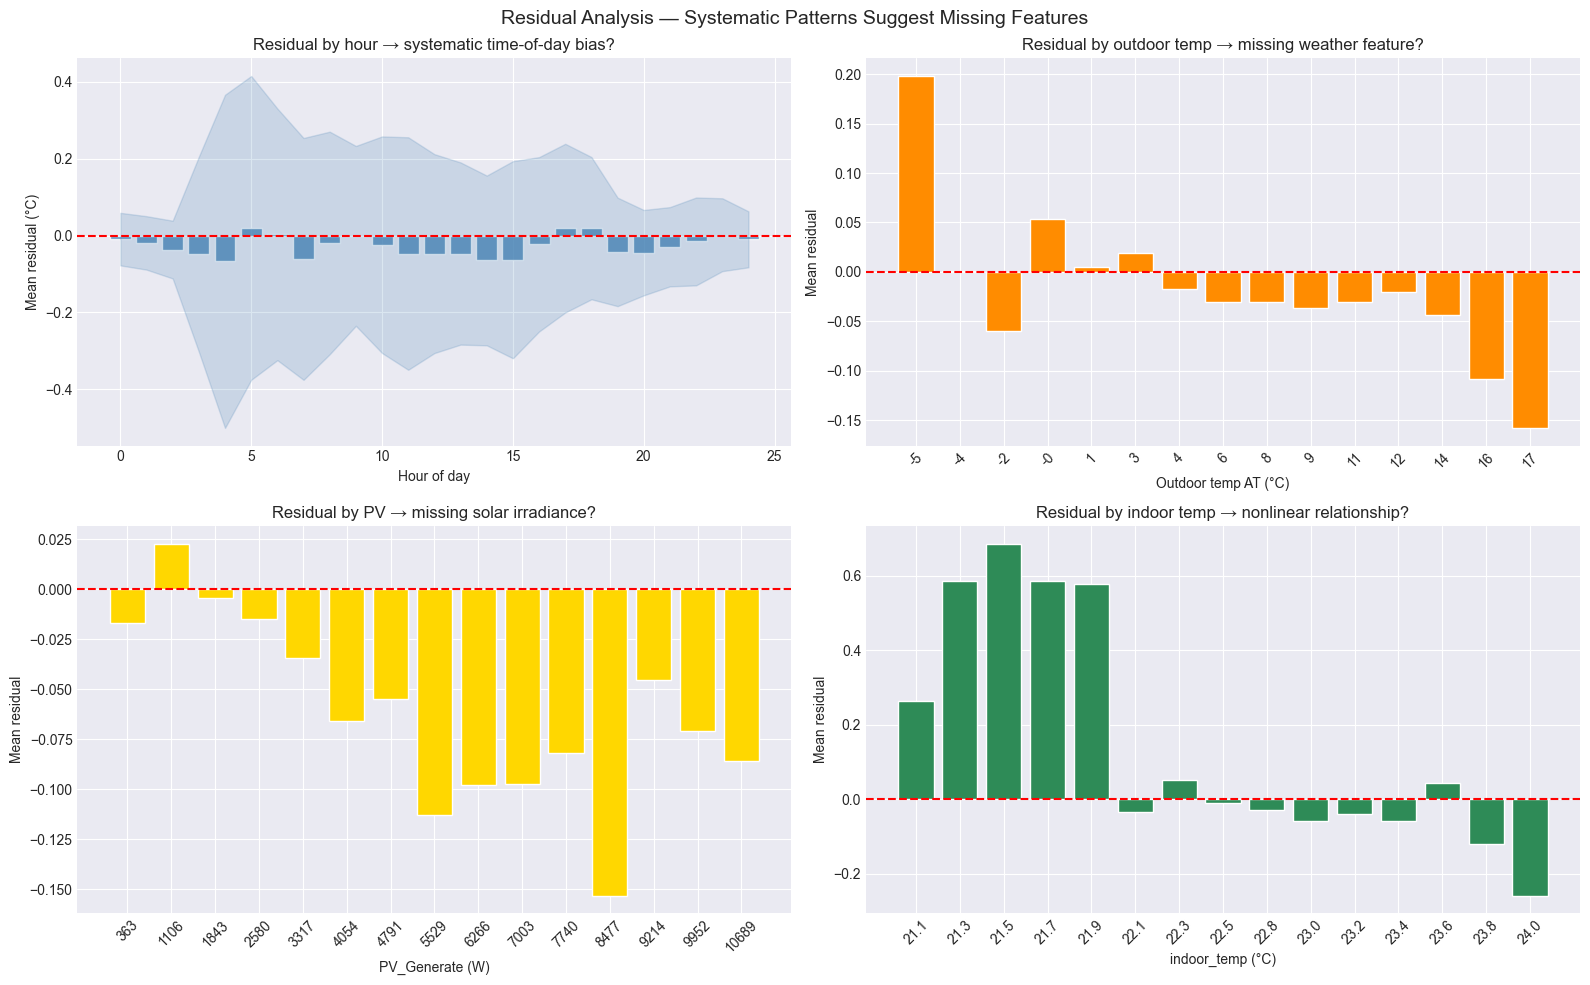

In [30]:
# ── Residual vs time-of-day: does the model systematically miss at certain hours? ─
# Reconstruct approximate hour from hour_sin, hour_cos
approx_hour = np.arctan2(val_df["hour_sin"], val_df["hour_cos"]) * 24 / (2 * np.pi) % 24
val_df["approx_hour"] = approx_hour

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Residual vs hour-of-day
hourly_residual = val_df.groupby(val_df["approx_hour"].round())["residual"].agg(["mean", "std"])
axes[0, 0].bar(hourly_residual.index, hourly_residual["mean"], color="steelblue",
               edgecolor="white", alpha=0.8)
axes[0, 0].fill_between(hourly_residual.index,
                        hourly_residual["mean"] - hourly_residual["std"],
                        hourly_residual["mean"] + hourly_residual["std"],
                        alpha=0.2, color="steelblue")
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_xlabel("Hour of day")
axes[0, 0].set_ylabel("Mean residual (°C)")
axes[0, 0].set_title("Residual by hour → systematic time-of-day bias?")

# 2. Residual vs outdoor temp
at_bins = pd.cut(val_df["AT"], bins=15)
at_residual = val_df.groupby(at_bins, observed=True)["residual"].mean()
axes[0, 1].bar(range(len(at_residual)), at_residual.values, color="darkorange", edgecolor="white")
axes[0, 1].set_xticks(range(len(at_residual)))
axes[0, 1].set_xticklabels([f"{x.mid:.0f}" for x in at_residual.index], rotation=45)
axes[0, 1].axhline(0, color="red", linestyle="--")
axes[0, 1].set_xlabel("Outdoor temp AT (°C)")
axes[0, 1].set_ylabel("Mean residual")
axes[0, 1].set_title("Residual by outdoor temp → missing weather feature?")

# 3. Residual vs PV_Generate
pv_bins = pd.cut(val_df["PV_Generate"].clip(upper=val_df["PV_Generate"].quantile(0.99)), bins=15)
pv_residual = val_df.groupby(pv_bins, observed=True)["residual"].mean()
axes[1, 0].bar(range(len(pv_residual)), pv_residual.values, color="gold", edgecolor="white")
axes[1, 0].set_xticks(range(len(pv_residual)))
axes[1, 0].set_xticklabels([f"{x.mid:.0f}" for x in pv_residual.index], rotation=45)
axes[1, 0].axhline(0, color="red", linestyle="--")
axes[1, 0].set_xlabel("PV_Generate (W)")
axes[1, 0].set_ylabel("Mean residual")
axes[1, 0].set_title("Residual by PV → missing solar irradiance?")

# 4. Residual vs indoor_temp
it_bins = pd.cut(val_df["indoor_temp"], bins=15)
it_residual = val_df.groupby(it_bins, observed=True)["residual"].mean()
axes[1, 1].bar(range(len(it_residual)), it_residual.values, color="seagreen", edgecolor="white")
axes[1, 1].set_xticks(range(len(it_residual)))
axes[1, 1].set_xticklabels([f"{x.mid:.1f}" for x in it_residual.index], rotation=45)
axes[1, 1].axhline(0, color="red", linestyle="--")
axes[1, 1].set_xlabel("indoor_temp (°C)")
axes[1, 1].set_ylabel("Mean residual")
axes[1, 1].set_title("Residual by indoor temp → nonlinear relationship?")

plt.suptitle("Residual Analysis — Systematic Patterns Suggest Missing Features", fontsize=14)
plt.tight_layout()
plt.show()

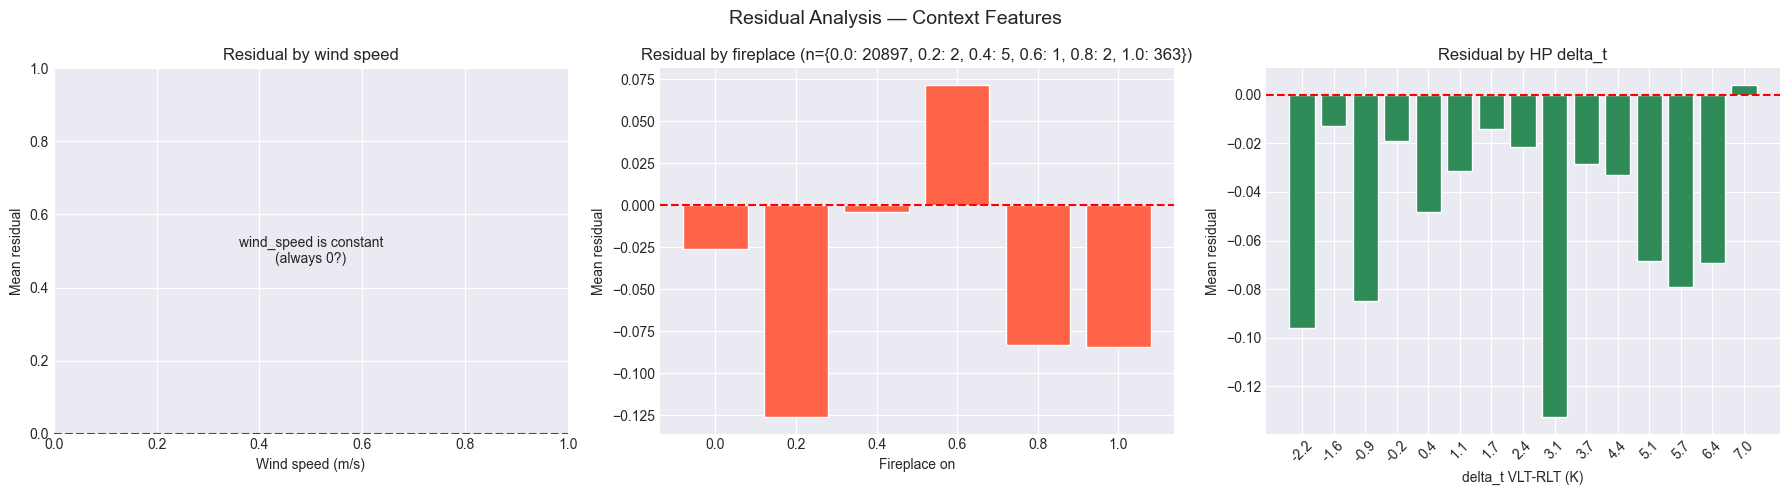

In [31]:
# ── Residual vs wind_speed and fireplace_on ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Residual by wind speed
if val_df["wind_speed"].nunique() > 1:
    ws_bins = pd.cut(val_df["wind_speed"], bins=10)
    ws_residual = val_df.groupby(ws_bins, observed=True)["residual"].mean()
    axes[0].bar(range(len(ws_residual)), ws_residual.values, color="steelblue", edgecolor="white")
    axes[0].set_xticks(range(len(ws_residual)))
    axes[0].set_xticklabels([f"{x.mid:.1f}" for x in ws_residual.index], rotation=45)
else:
    axes[0].text(0.5, 0.5, "wind_speed is constant\n(always 0?)",
                ha="center", va="center", transform=axes[0].transAxes)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Wind speed (m/s)")
axes[0].set_ylabel("Mean residual")
axes[0].set_title("Residual by wind speed")

# Residual by fireplace status
fp_residual = val_df.groupby("fireplace_on")["residual"].agg(["mean", "std", "count"])
axes[1].bar(fp_residual.index.astype(str), fp_residual["mean"], color="tomato", edgecolor="white")
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Fireplace on")
axes[1].set_ylabel("Mean residual")
axes[1].set_title(f"Residual by fireplace (n={fp_residual['count'].to_dict()})")

# Residual by delta_t (HP activity)
dt_bins = pd.cut(val_df["delta_t"], bins=15)
dt_residual = val_df.groupby(dt_bins, observed=True)["residual"].mean()
axes[2].bar(range(len(dt_residual)), dt_residual.values, color="seagreen", edgecolor="white")
axes[2].set_xticks(range(len(dt_residual)))
axes[2].set_xticklabels([f"{x.mid:.1f}" for x in dt_residual.index], rotation=45)
axes[2].axhline(0, color="red", linestyle="--")
axes[2].set_xlabel("delta_t VLT-RLT (K)")
axes[2].set_ylabel("Mean residual")
axes[2].set_title("Residual by HP delta_t")

plt.suptitle("Residual Analysis — Context Features", fontsize=14)
plt.tight_layout()
plt.show()

## 13. SHAP Analysis (Optional)

SHAP values reveal **feature interactions** that simple permutation importance misses.
This is especially important when `indoor_temp` dominates — SHAP shows *how* the model
uses each feature conditionally.

Computing SHAP values (this may take a few minutes)…


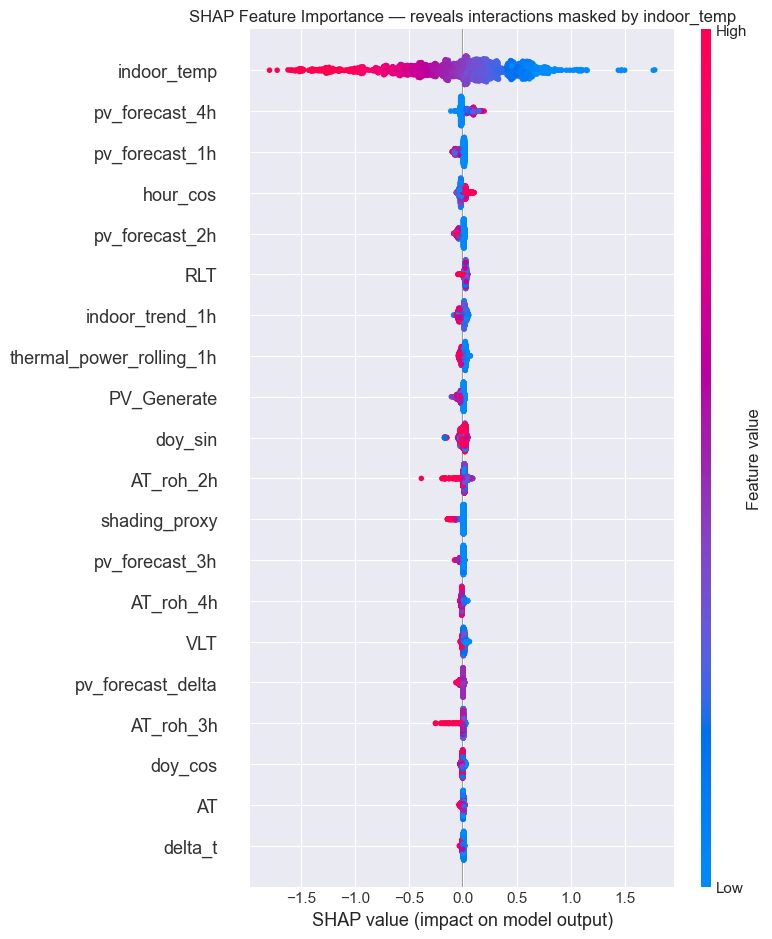

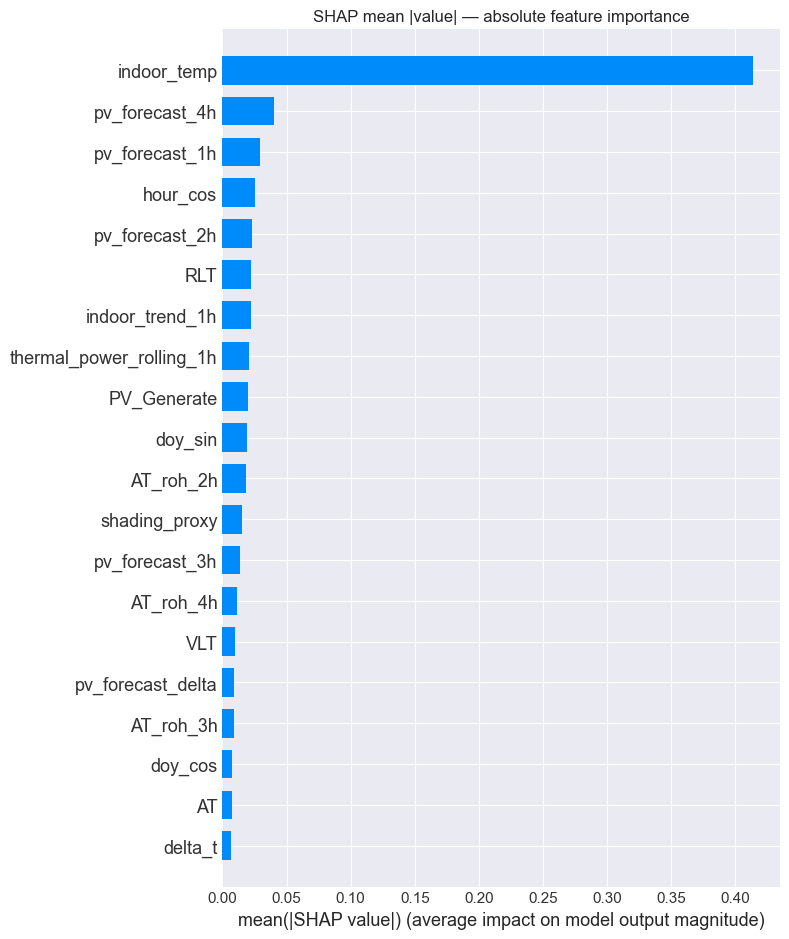

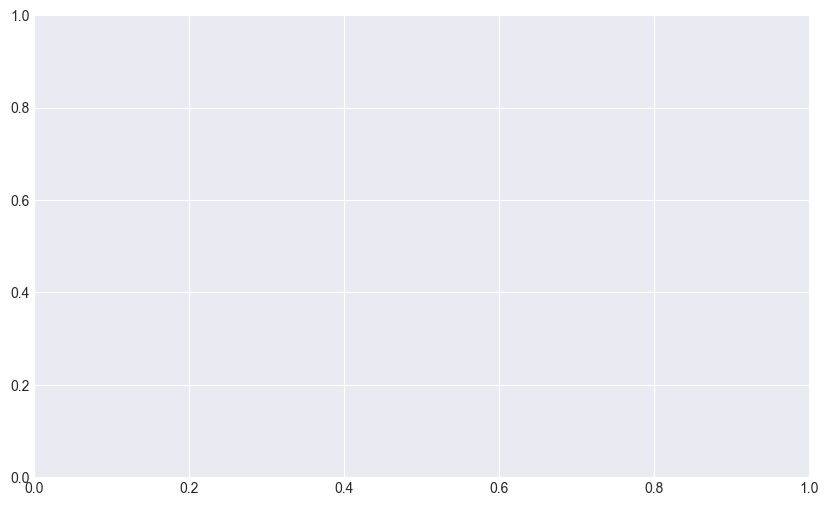

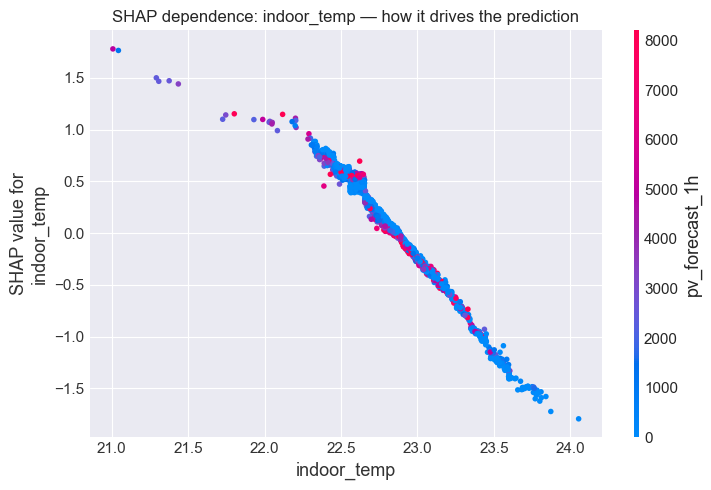

In [32]:
if USE_SHAP:
    print("Computing SHAP values (this may take a few minutes)…")
    # Use a subsample for speed
    shap_sample_n = min(2000, len(X_val))
    shap_idx = np.random.RandomState(42).choice(len(X_val), shap_sample_n, replace=False)
    X_shap = X_val[shap_idx]

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_shap)

    # Summary plot
    fig, ax = plt.subplots(figsize=(12, 10))
    shap.summary_plot(shap_values, X_shap, feature_names=FEATURE_COLS, show=False)
    plt.title("SHAP Feature Importance — reveals interactions masked by indoor_temp")
    plt.tight_layout()
    plt.show()

    # Bar plot
    fig, ax = plt.subplots(figsize=(12, 8))
    shap.summary_plot(shap_values, X_shap, feature_names=FEATURE_COLS,
                      plot_type="bar", show=False)
    plt.title("SHAP mean |value| — absolute feature importance")
    plt.tight_layout()
    plt.show()

    # Dependence plot for indoor_temp
    fig, ax = plt.subplots(figsize=(10, 6))
    shap.dependence_plot("indoor_temp", shap_values, X_shap,
                         feature_names=FEATURE_COLS, show=False)
    plt.title("SHAP dependence: indoor_temp — how it drives the prediction")
    plt.tight_layout()
    plt.show()
else:
    print("SHAP not available — install with: pip install shap")
    print("SHAP would show feature interactions that explain WHY indoor_temp dominates.")

## 14. Full Diagnostic Dashboard

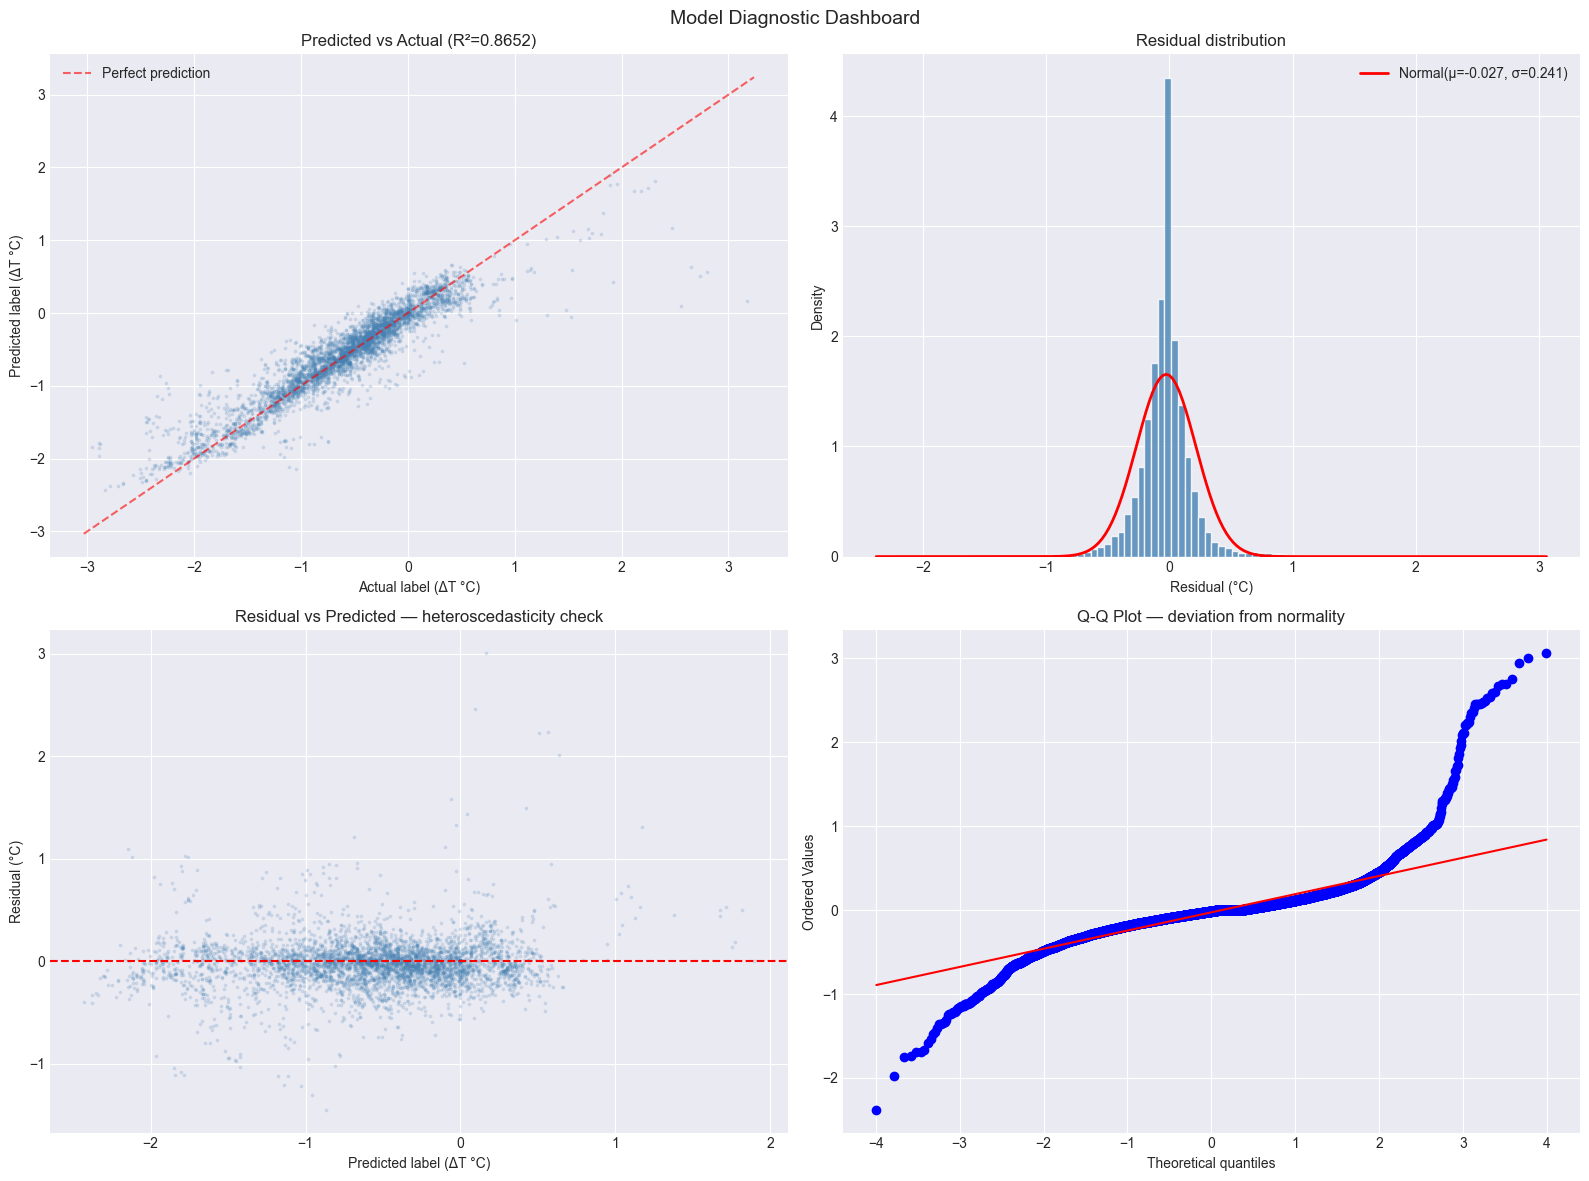

In [33]:
# ── Predicted vs Actual + Residual distribution + Residual vs Predicted ──────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Predicted vs actual scatter
sample_idx_diag = np.random.RandomState(42).choice(len(y_val), min(5000, len(y_val)), replace=False)
axes[0, 0].scatter(y_val[sample_idx_diag], y_pred[sample_idx_diag],
                   alpha=0.15, s=3, color="steelblue")
lims = [min(y_val.min(), y_pred.min()), max(y_val.max(), y_pred.max())]
axes[0, 0].plot(lims, lims, "r--", alpha=0.6, label="Perfect prediction")
axes[0, 0].set_xlabel("Actual label (ΔT °C)")
axes[0, 0].set_ylabel("Predicted label (ΔT °C)")
axes[0, 0].set_title(f"Predicted vs Actual (R²={val_r2:.4f})")
axes[0, 0].legend()

# 2. Residual histogram
axes[0, 1].hist(residuals, bins=100, color="steelblue", edgecolor="white", alpha=0.8, density=True)
# Overlay normal distribution
from scipy import stats
x_norm = np.linspace(residuals.min(), residuals.max(), 200)
axes[0, 1].plot(x_norm, stats.norm.pdf(x_norm, residuals.mean(), residuals.std()),
                "r-", linewidth=2, label=f"Normal(μ={residuals.mean():.3f}, σ={residuals.std():.3f})")
axes[0, 1].set_xlabel("Residual (°C)")
axes[0, 1].set_ylabel("Density")
axes[0, 1].set_title("Residual distribution")
axes[0, 1].legend()

# 3. Residual vs predicted (heteroscedasticity)
axes[1, 0].scatter(y_pred[sample_idx_diag], residuals[sample_idx_diag],
                   alpha=0.15, s=3, color="steelblue")
axes[1, 0].axhline(0, color="red", linestyle="--")
axes[1, 0].set_xlabel("Predicted label (ΔT °C)")
axes[1, 0].set_ylabel("Residual (°C)")
axes[1, 0].set_title("Residual vs Predicted — heteroscedasticity check")

# 4. Q-Q plot
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot — deviation from normality")

plt.suptitle("Model Diagnostic Dashboard", fontsize=14)
plt.tight_layout()
plt.show()

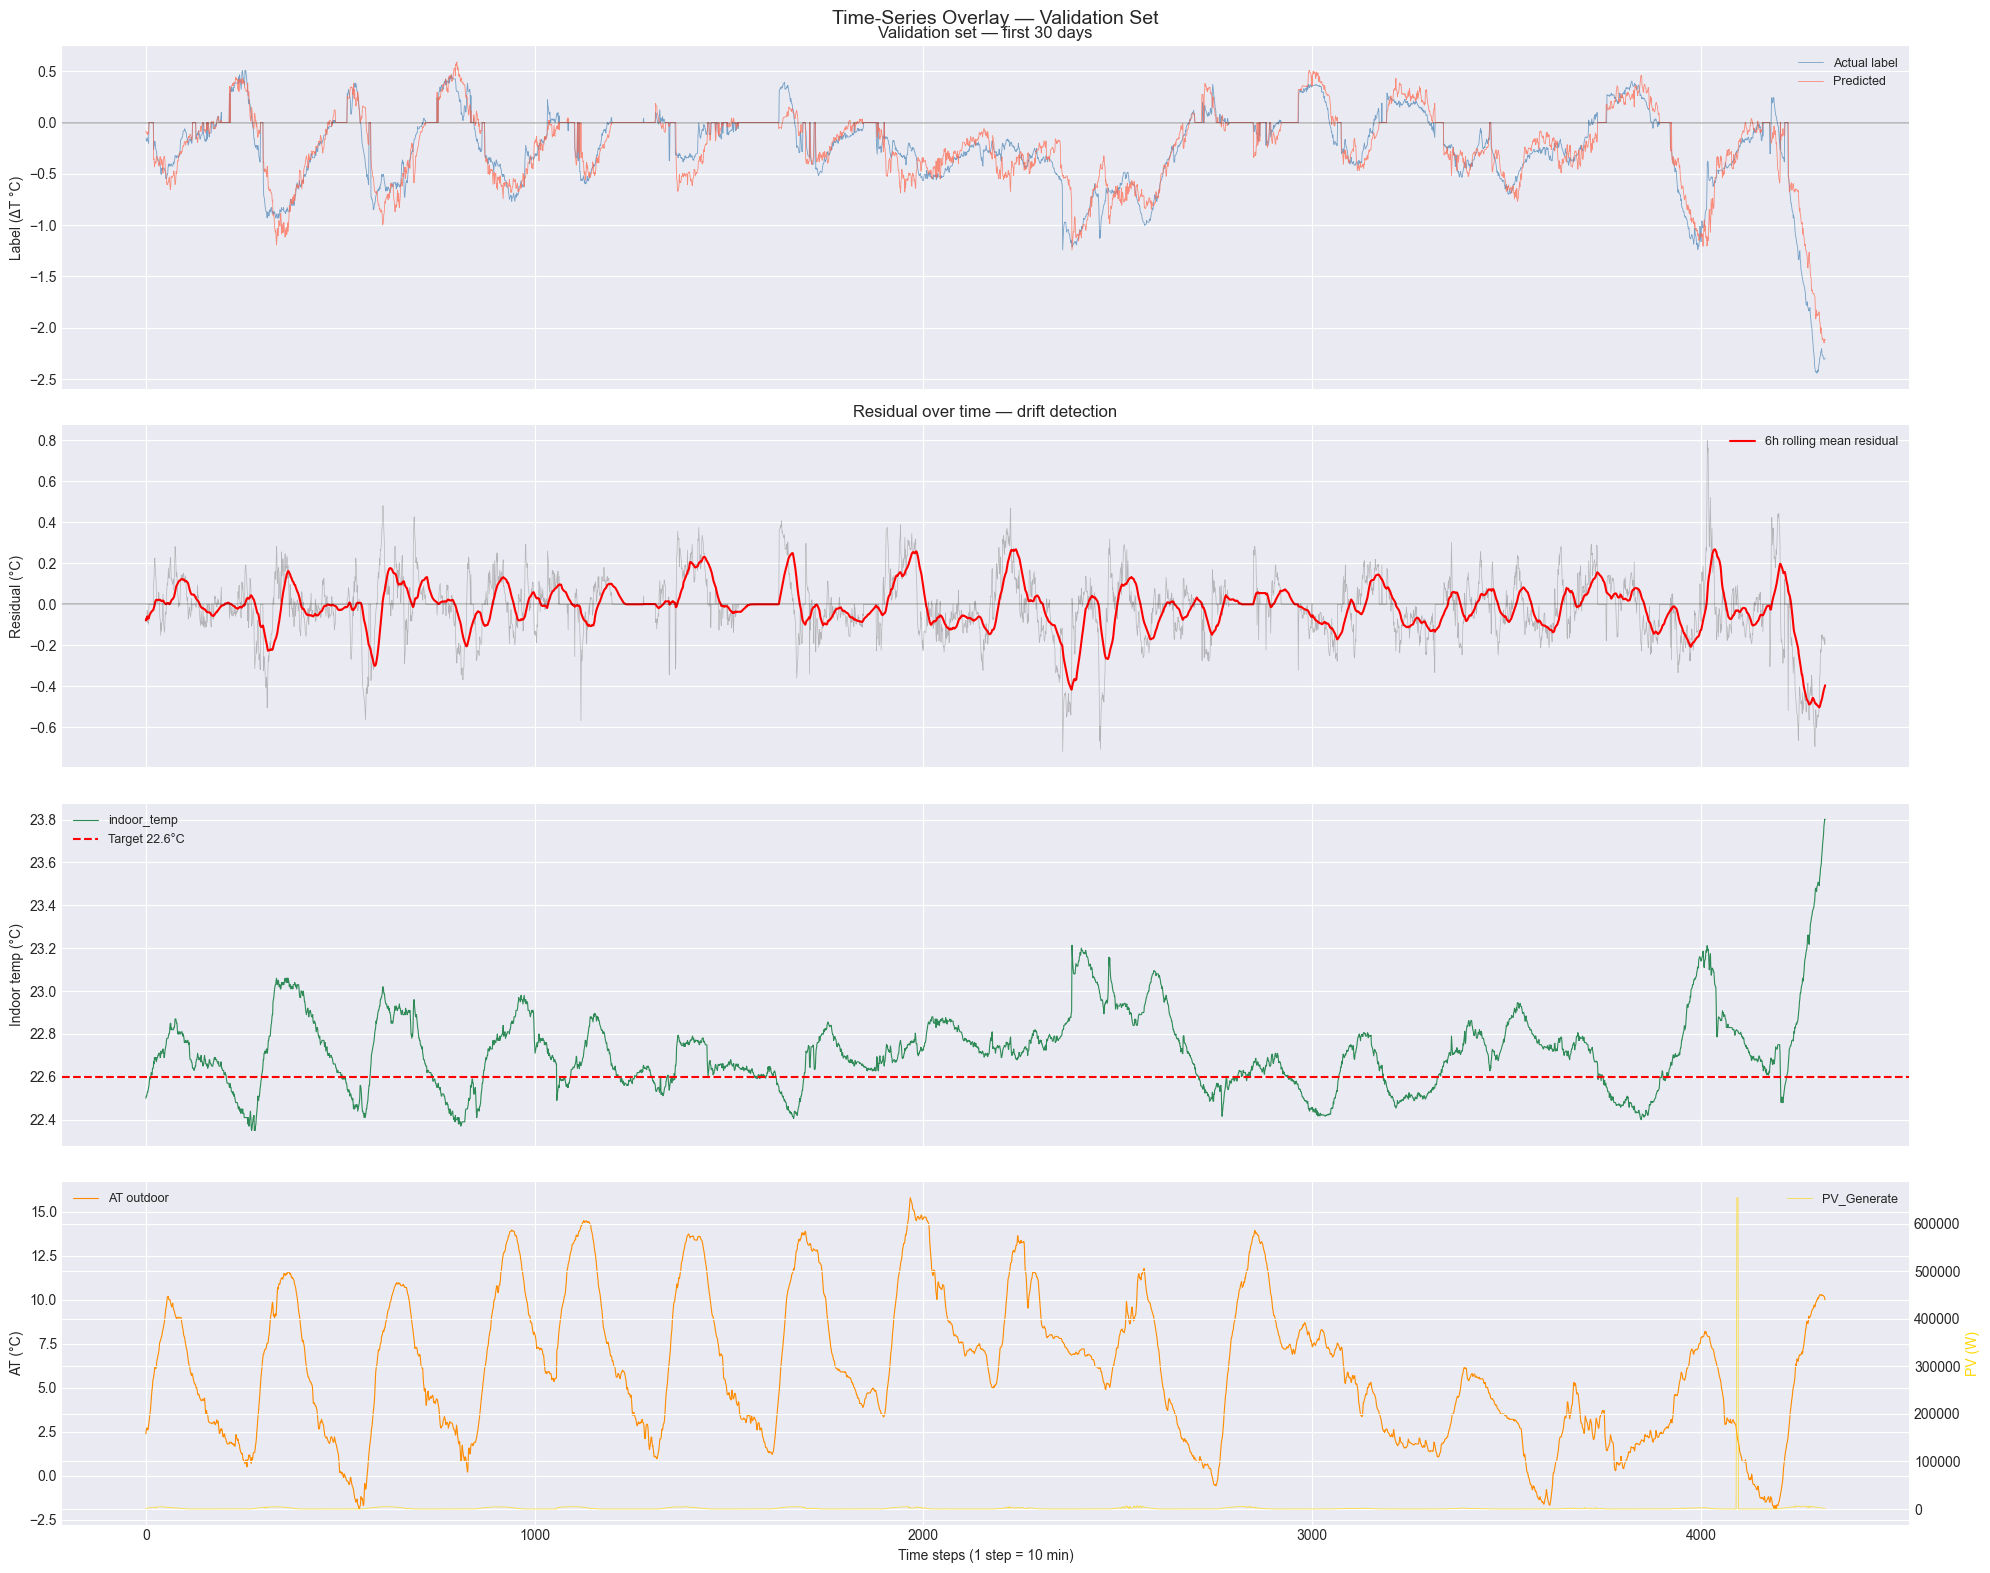

In [34]:
# ── Time-series overlay: predicted vs actual label (30-day window) ─────────────
n_plot = min(len(val_df), 30 * 24 * STEPS_PER_HOUR)  # 30 days
plot_idx = range(n_plot)

fig, axes = plt.subplots(4, 1, figsize=(20, 16), sharex=True)

# 1. Actual vs predicted label
axes[0].plot(plot_idx, y_val[:n_plot], color="steelblue", linewidth=0.6, alpha=0.7, label="Actual label")
axes[0].plot(plot_idx, y_pred[:n_plot], color="tomato", linewidth=0.6, alpha=0.7, label="Predicted")
axes[0].axhline(0, color="black", linestyle="-", linewidth=0.3)
axes[0].set_ylabel("Label (ΔT °C)")
axes[0].set_title("Validation set — first 30 days")
axes[0].legend(fontsize=9)

# 2. Residual over time
axes[1].plot(plot_idx, residuals[:n_plot], color="grey", linewidth=0.5, alpha=0.5)
# Rolling mean of residual
res_rolling = pd.Series(residuals[:n_plot]).rolling(STEPS_PER_HOUR * 6, min_periods=1).mean()
axes[1].plot(plot_idx, res_rolling, color="red", linewidth=1.5, label="6h rolling mean residual")
axes[1].axhline(0, color="black", linestyle="-", linewidth=0.3)
axes[1].set_ylabel("Residual (°C)")
axes[1].set_title("Residual over time — drift detection")
axes[1].legend(fontsize=9)

# 3. Indoor temp
axes[2].plot(plot_idx, val_df["indoor_temp"].values[:n_plot],
             color="seagreen", linewidth=0.8, label="indoor_temp")
axes[2].axhline(HEATING_TARGET_C, color="red", linestyle="--", label=f"Target {HEATING_TARGET_C}°C")
axes[2].set_ylabel("Indoor temp (°C)")
axes[2].legend(fontsize=9)

# 4. Outdoor temp + PV
axes[3].plot(plot_idx, val_df["AT"].values[:n_plot],
             color="darkorange", linewidth=0.8, label="AT outdoor")
ax_pv = axes[3].twinx()
ax_pv.plot(plot_idx, val_df["PV_Generate"].values[:n_plot],
           color="gold", linewidth=0.6, alpha=0.7, label="PV_Generate")
ax_pv.set_ylabel("PV (W)", color="gold")
axes[3].set_xlabel(f"Time steps (1 step = {60//STEPS_PER_HOUR} min)")
axes[3].set_ylabel("AT (°C)")
axes[3].legend(loc="upper left", fontsize=9)
ax_pv.legend(loc="upper right", fontsize=9)

plt.suptitle("Time-Series Overlay — Validation Set", fontsize=14)
plt.tight_layout()
plt.show()

## 15. Missing Feature Candidates — Summary

Based on the residual analysis and feature importance investigation, these are the
candidate features that could improve the model:

In [35]:
# ── Quantify residual patterns to identify missing feature candidates ─────────
print("╔══════════════════════════════════════════════════════════════════════════╗")
print("║              MISSING FEATURE CANDIDATE ANALYSIS                        ║")
print("╠══════════════════════════════════════════════════════════════════════════╣")
print("║                                                                        ║")

# 1. Time-of-day bias
hourly_bias = val_df.groupby(val_df["approx_hour"].round())["residual"].mean()
max_hourly_bias = hourly_bias.abs().max()
worst_hour = hourly_bias.abs().idxmax()
print(f"║  1. TIME-OF-DAY BIAS                                                  ║")
print(f"║     Max hourly residual bias: {max_hourly_bias:.4f}°C at hour {worst_hour:.0f}         ║")
if max_hourly_bias > 0.02:
    print(f"║     → SIGNIFICANT: suggests missing solar/occupancy pattern feature    ║")
else:
    print(f"║     → Low: cyclical time features capture daily patterns well          ║")

# 2. Outdoor temp dependence
at_bias = val_df.groupby(pd.cut(val_df["AT"], bins=10), observed=True)["residual"].mean()
max_at_bias = at_bias.abs().max()
print(f"║                                                                        ║")
print(f"║  2. OUTDOOR TEMP DEPENDENCE                                            ║")
print(f"║     Max AT-bin residual bias: {max_at_bias:.4f}°C                       ║")
if max_at_bias > 0.03:
    print(f"║     → SIGNIFICANT: suggests missing building-envelope heat loss model  ║")
else:
    print(f"║     → Low: AT features capture outdoor temp effects adequately         ║")

# 3. PV / solar dependence
pv_nonzero = val_df[val_df["PV_Generate"] > 10]
if len(pv_nonzero) > 100:
    pv_bias = pv_nonzero.groupby(pd.cut(pv_nonzero["PV_Generate"], bins=10), observed=True)["residual"].mean()
    max_pv_bias = pv_bias.abs().max()
else:
    max_pv_bias = 0.0
print(f"║                                                                        ║")
print(f"║  3. SOLAR / PV DEPENDENCE                                              ║")
print(f"║     Max PV-bin residual bias: {max_pv_bias:.4f}°C                       ║")
if max_pv_bias > 0.03:
    print(f"║     → SIGNIFICANT: PV ≠ solar irradiance — consider adding irradiance  ║")
    print(f"║       sensor (global horizontal / plane-of-array radiation)             ║")
else:
    print(f"║     → Low: PV features capture solar gain effects adequately           ║")

# 4. Constant features that contribute nothing
const_features = [f for f in FEATURE_COLS if model_df[f].nunique() <= 2 and model_df[f].std() < 0.01]
print(f"║                                                                        ║")
print(f"║  4. NEAR-CONSTANT FEATURES (always same value)                         ║")
if const_features:
    for cf in const_features:
        print(f"║     {cf:35s} (std={model_df[cf].std():.4f})          ║")
else:
    print(f"║     None detected                                                     ║")

print(f"║                                                                        ║")
print(f"║  CANDIDATE MISSING FEATURES:                                           ║")
print(f"║                                                                        ║")
print(f"║  • Solar irradiance sensor (W/m²) — not just PV output                 ║")
print(f"║    PV output depends on panel orientation, inverter efficiency, shading  ║")
print(f"║    A direct irradiance sensor would give true solar gain signal.         ║")
print(f"║                                                                        ║")
print(f"║  • Floor slab temperature — thermal mass state indicator                ║")
print(f"║    RLT approximates slab temp but lags behind. Direct measurement       ║")
print(f"║    would capture accumulated thermal energy more accurately.             ║")
print(f"║                                                                        ║")
print(f"║  • Room-by-room temperature spread                                     ║")
print(f"║    indoor_temp is the median of all rooms. Temperature VARIANCE across  ║")
print(f"║    rooms would indicate uneven heating / cooling.                        ║")
print(f"║                                                                        ║")
print(f"║  • Humidity (indoor or outdoor)                                        ║")
print(f"║    Affects thermal comfort and actual heat transfer coefficients.        ║")
print(f"║                                                                        ║")
print(f"║  • Heating curve offset setting                                        ║")
print(f"║    If the heat pump has an adjustable heating curve, the current offset  ║")
print(f"║    affects the baseline VLT the model tries to correct.                  ║")
print(f"║                                                                        ║")
print(f"║  • Accumulated thermal energy (cumulative Q_wp over last N hours)       ║")
print(f"║    Better than instantaneous Q_wp for slow-responding floor heating.     ║")
print("╚══════════════════════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════════════════════╗
║              MISSING FEATURE CANDIDATE ANALYSIS                        ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                        ║
║  1. TIME-OF-DAY BIAS                                                  ║
║     Max hourly residual bias: 0.0670°C at hour 4         ║
║     → SIGNIFICANT: suggests missing solar/occupancy pattern feature    ║
║                                                                        ║
║  2. OUTDOOR TEMP DEPENDENCE                                            ║
║     Max AT-bin residual bias: 0.1505°C                       ║
║     → SIGNIFICANT: suggests missing building-envelope heat loss model  ║
║                                                                        ║
║  3. SOLAR / PV DEPENDENCE                                              ║
║     Max PV-bin residual bias: 0.0509°C      

### 15b. Concrete Improvement Recommendations

| Priority | Change | Expected Impact | Cost |
|----------|--------|-----------------|------|
| **1** | **Residualize the label** in the calibration script: train on `adjusted_label = -(T_future - T_current)/S_H` instead of `-(T_future - T_target)/S_H`. Add `indoor_margin` as a separate bias term in inference. | Eliminates indoor_temp dominance; forces model to learn actual thermal dynamics | Code-only, zero external cost |
| **2** | **Add `cumulative_Q_wp_4h`** (rolling 4h sum of Q_wp) as a feature — measures thermal energy already stored in the floor slab | Captures slow thermal mass response of underfloor heating that instantaneous Q_wp misses | Compute from existing data |
| **3** | **Add room temp variance** (`std(RT_Flur_OG, RT_Bad_OG, RT_WZ, RT_Flur_EG)`) | Detects uneven heating zones — large variance means some rooms need more correction | Already available in sensor data |
| **4** | **Add solar irradiance** from weather API (`shortwave_radiation` in OpenMeteo) | PV output ≠ solar thermal gain. Irradiance captures true solar heating on the building envelope | Free API call, 1 new sensor entity |
| **5** | **Prune correlated feature clusters** — keep one representative per group (e.g., keep `indoor_margin` instead of `indoor_temp`, keep `Q_wp` instead of `thermal_power_w`) | Reduces noise, improves permutation importance interpretability, slightly faster inference | Code-only |
| **6** | **Add humidity** (indoor or outdoor) | Affects real U-value and thermal comfort | Sensor or weather API |

In [36]:
# ── Test new features that can be engineered from existing data ────────────────
print("Engineering new candidate features from existing columns…\n")

df_new = model_df.copy()

# 1. Cumulative thermal energy over label horizon (4h = 24 steps)
df_new["cumulative_Q_wp_4h"] = df_new["Q_wp"].rolling(24, min_periods=1).sum()

# 2. Indoor temp acceleration (2nd derivative — is warming/cooling accelerating?)
df_new["indoor_accel"] = df_new["indoor_trend_1h"].diff(1).fillna(0)

# 3. AT forecast trend (anticipated outdoor change)
df_new["AT_forecast_trend"] = df_new["AT_roh_4h"] - df_new["AT"]

# 4. Cumulative PV over label horizon
df_new["pv_cumulative_4h"] = df_new["PV_Generate"].rolling(24, min_periods=1).sum()

# 5. Thermal momentum: HP effort × effectiveness
df_new["thermal_momentum"] = df_new["thermal_power_rolling_1h"] * df_new["delta_t"]

NEW_FEATURES = ["cumulative_Q_wp_4h", "indoor_accel", "AT_forecast_trend",
                "pv_cumulative_4h", "thermal_momentum"]

# Train with original features + new features
extended_feats = FEATURE_COLS + NEW_FEATURES
X_ext = df_new[extended_feats].dropna().values
y_ext = df_new.loc[df_new[extended_feats].dropna().index, "label"].values
split_ext = int(len(X_ext) * TRAIN_FRACTION)

m_ext = lgb.LGBMRegressor(**LGB_PARAMS)
m_ext.fit(
    X_ext[:split_ext], y_ext[:split_ext],
    eval_set=[(X_ext[split_ext:], y_ext[split_ext:])],
    eval_metric="mae",
    callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(0)],
)
yp_ext = m_ext.predict(X_ext[split_ext:])
ext_mae = mean_absolute_error(y_ext[split_ext:], yp_ext)
ext_r2 = r2_score(y_ext[split_ext:], yp_ext)

print(f"=== NEW FEATURE EXPERIMENT ===")
print(f"  Original ({len(FEATURE_COLS)} feats):  MAE={val_mae:.4f}  R²={val_r2:.4f}")
print(f"  Extended ({len(extended_feats)} feats):  MAE={ext_mae:.4f}  R²={ext_r2:.4f}")
print(f"  Improvement: MAE Δ={ext_mae - val_mae:+.4f}  R² Δ={ext_r2 - val_r2:+.4f}")

# Check importance of new features
fi_ext = dict(zip(extended_feats, m_ext.feature_importances_))
print(f"\n  New feature split-based importance:")
for f in NEW_FEATURES:
    print(f"    {f:25s}  splits={fi_ext.get(f, 0):>4d}")

Engineering new candidate features from existing columns…

=== NEW FEATURE EXPERIMENT ===
  Original (52 feats):  MAE=0.1448  R²=0.8652
  Extended (57 feats):  MAE=0.1413  R²=0.8677
  Improvement: MAE Δ=-0.0035  R² Δ=+0.0025

  New feature split-based importance:
    cumulative_Q_wp_4h         splits= 112
    indoor_accel               splits=  16
    AT_forecast_trend          splits=  35
    pv_cumulative_4h           splits=  17
    thermal_momentum           splits=  21


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 16. Summary & Conclusions

In [37]:
print("="*72)
print("  HEATING CORRECTION ML — STANDALONE TRAINING SUMMARY")
print("="*72)
print(f"")
print(f"  Data           : {len(model_df):,} rows, {len(FEATURE_COLS)} features")
print(f"  Training split : {len(X_train):,} train / {len(X_val):,} validation")
print(f"  Label          : mean={y.mean():.3f}  std={y.std():.3f}")
print(f"")
print(f"  ── Model Performance ──")
print(f"  Val MAE        : {val_mae:.4f}°C")
print(f"  Val R²         : {val_r2:.4f}")
if 'cv_maes' in dir():
    print(f"  CV MAE         : {np.mean(cv_maes):.4f} ± {np.std(cv_maes):.4f}")
    print(f"  CV R²          : {np.mean(cv_r2s):.4f} ± {np.std(cv_r2s):.4f}")
print(f"")
print(f"  ── indoor_temp Dominance ──")
print(f"  Permutation importance: indoor_temp = {pi.get('indoor_temp', 0):.4f}")
print(f"  Next best feature     : {pi_sorted[1][0]} = {pi_sorted[1][1]:.4f}")
print(f"  Ratio                 : {pi.get('indoor_temp', 1) / max(pi_sorted[1][1], 1e-9):.0f}x")
print(f"")
print(f"  ── Key Insight ──")
print(f"  The label is: -(T_future - T_target) / S_H")
print(f"  T_future ≈ T_current (thermal inertia) → indoor_temp is a near-")
print(f"  perfect proxy for the label. This masks other features' importance.")
print(f"  To see the true value of other features, remove indoor_temp and")
print(f"  use indoor_margin instead (Section 11c/11d above).")
print(f"")
print("="*72)

  HEATING CORRECTION ML — STANDALONE TRAINING SUMMARY

  Data           : 85,078 rows, 52 features
  Training split : 63,808 train / 21,270 validation
  Label          : mean=-0.507  std=0.676

  ── Model Performance ──
  Val MAE        : 0.1448°C
  Val R²         : 0.8652
  CV MAE         : 0.1475 ± 0.0159
  CV R²          : 0.8196 ± 0.0337

  ── indoor_temp Dominance ──
  Permutation importance: indoor_temp = 0.4905
  Next best feature     : pv_forecast_4h = 0.0138
  Ratio                 : 36x

  ── Key Insight ──
  The label is: -(T_future - T_target) / S_H
  T_future ≈ T_current (thermal inertia) → indoor_temp is a near-
  perfect proxy for the label. This masks other features' importance.
  To see the true value of other features, remove indoor_temp and
  use indoor_margin instead (Section 11c/11d above).

